In [159]:
import pandas as pd

df = pd.read_csv("Trees.csv") 

# Key columns
cols = ["DBH", "CROWN_AREA", "CROWN_HEIGHT"]

# Create a summary of missing values for the key columns
missing_summary = pd.DataFrame({
    "Missing Count": df[cols].isna().sum(),
    "Total Count": len(df),
})

missing_summary["Missing %"] = (missing_summary["Missing Count"] / len(df)) * 100

missing_summary

,Missing Count,Total Count,Missing %
DBH,0,55676,0.000000
CROWN_AREA,12684,55676,22.781809
CROWN_HEIGHT,29,55676,0.052087


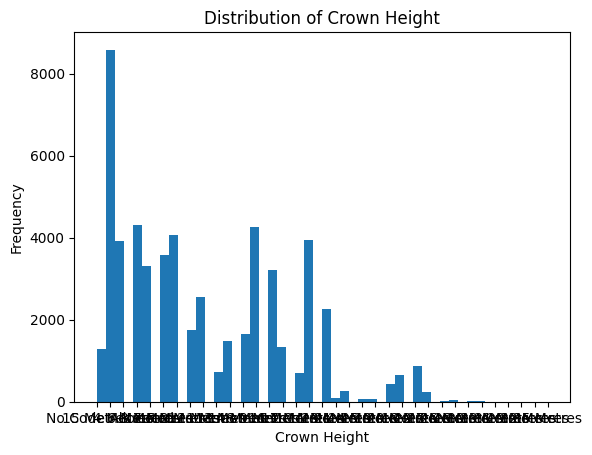

count                 55647
unique                   35
top       No Code Allocated
freq                   8583
Name: CROWN_HEIGHT, dtype: object

In [160]:
import matplotlib.pyplot as plt

#plot the distribution of crown height values
plt.hist(df["CROWN_HEIGHT"].dropna(), bins=50)
plt.xlabel("Crown Height")
plt.ylabel("Frequency")
plt.title("Distribution of Crown Height")
plt.show()
df["CROWN_HEIGHT"].describe()

In [161]:
# Check data types
print(df[["DBH", "CROWN_HEIGHT", "CROWN_AREA"]].dtypes)

# Check first 20 values to see what the data actually looks like
print(df["DBH"].head(20))
print(df["CROWN_HEIGHT"].head(20))
print(df["CROWN_AREA"].head(20))

DBH             object
CROWN_HEIGHT    object
CROWN_AREA      object
dtype: object
0     No Code Allocated
1     No Code Allocated
2         7 Centimetres
3         6 Centimetres
4     No Code Allocated
5        10 Centimetres
6         8 Centimetres
7        10 Centimetres
8        11 Centimetres
9        12 Centimetres
10       21 Centimetres
11       18 Centimetres
12    No Code Allocated
13       20 Centimetres
14       10 Centimetres
15        9 Centimetres
16       12 Centimetres
17       15 Centimetres
18       10 Centimetres
19       10 Centimetres
Name: DBH, dtype: object
0             15 Metres
1     No Code Allocated
2              4 Metres
3              4 Metres
4     No Code Allocated
5              6 Metres
6              4 Metres
7              6 Metres
8              3 Metres
9              7 Metres
10             5 Metres
11             7 Metres
12    No Code Allocated
13             4 Metres
14             4 Metres
15             4 Metres
16             3 Metres
17  

In [162]:
#now we know that there's categorical data, clean both the crown height and dbh columns 
# so that they only contain numerical values.

df["DBH_clean"] = (
    df["DBH"]
    .str.replace(" Centimetres", "", regex=False)
    .replace("No Code Allocated", pd.NA)
)

df["DBH_clean"] = pd.to_numeric(df["DBH_clean"], errors="coerce")

df["CROWN_HEIGHT_clean"] = (
    df["CROWN_HEIGHT"]
    .str.replace(" Metres", "", regex=False)
    .replace("No Code Allocated", pd.NA)
)

df["CROWN_HEIGHT_clean"] = pd.to_numeric(df["CROWN_HEIGHT_clean"], errors="coerce")

In [163]:
#check the data types are floats and first few values
print(df[["DBH_clean", "CROWN_HEIGHT_clean"]].dtypes)
print(df[["DBH_clean", "CROWN_HEIGHT_clean"]].head())

#check the percentage of missing values in the cleaned columns because
#'no code allocated' was replaced with NA and should be counted as missing
df[["DBH_clean", "CROWN_HEIGHT_clean"]].isna().mean() * 100

DBH_clean             float64
CROWN_HEIGHT_clean    float64
dtype: object
   DBH_clean  CROWN_HEIGHT_clean
0        NaN                15.0
1        NaN                 NaN
2        7.0                 4.0
3        6.0                 4.0
4        NaN                 NaN


DBH_clean             10.253969
CROWN_HEIGHT_clean    15.468065
dtype: float64

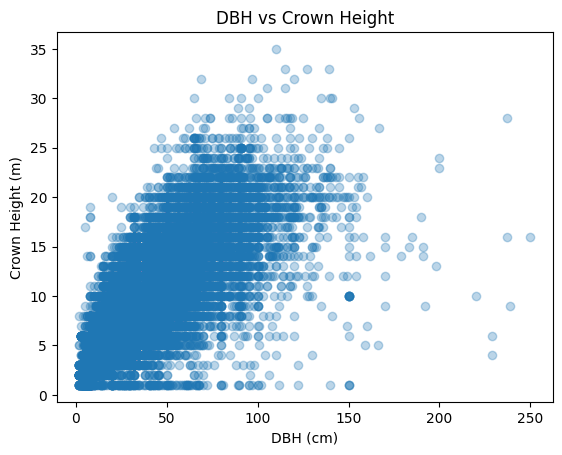

In [164]:
#plot the relationship between DBH and crown height using a scatter plot
plot_df = df[["DBH_clean", "CROWN_HEIGHT_clean"]].dropna()

plt.scatter(plot_df["DBH_clean"], plot_df["CROWN_HEIGHT_clean"], alpha=0.3)
plt.xlabel("DBH (cm)")
plt.ylabel("Crown Height (m)")
plt.title("DBH vs Crown Height")
plt.show()

In [165]:
from sklearn.linear_model import LinearRegression
import numpy as np

#Model training
model_df = df[["DBH_clean", "CROWN_HEIGHT_clean"]].dropna()

X = model_df[["DBH_clean"]]
y = model_df["CROWN_HEIGHT_clean"]

#Linear regression model
lin_model = LinearRegression().fit(X, y)
y_pred_lin = lin_model.predict(X)

#Log model
X_log = np.log1p(model_df[["DBH_clean"]])

log_model = LinearRegression().fit(X_log, y)
y_pred_log = log_model.predict(X_log)

#Power law model
X_power = np.log(model_df["DBH_clean"])
y_power = np.log(model_df["CROWN_HEIGHT_clean"])

power_model = LinearRegression().fit(X_power.values.reshape(-1,1), y_power)

y_pred_power = np.exp(power_model.predict(X_power.values.reshape(-1,1)))



Linear RMSE: 2.9005645307366774
Log RMSE: 2.937915322242821
Power RMSE: 2.8366746743835396


/Users/oliviabrannan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/oliviabrannan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


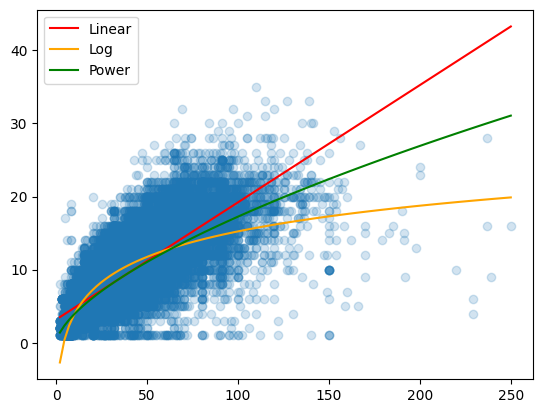

In [166]:
from sklearn.metrics import mean_squared_error

#calculate RMSE for each model
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Linear RMSE:", rmse(y, y_pred_lin))
print("Log RMSE:", rmse(y, y_pred_log))
print("Power RMSE:", rmse(y, y_pred_power))

plt.scatter(X, y, alpha=0.2)

x_range = np.linspace(X.min(), X.max(), 100)

#plot the predictions of each model
plt.plot(x_range, lin_model.predict(x_range.reshape(-1,1)), label="Linear", color="red")
plt.plot(x_range, log_model.predict(np.log1p(x_range).reshape(-1,1)), label="Log", color="orange")
plt.plot(x_range, np.exp(power_model.predict(np.log(x_range).reshape(-1,1))), label="Power", color="green")

plt.legend()
plt.show()

In [167]:
species_height_summary = (
    df.groupby("COMMON_NAME")
      .agg(
          total_rows=("COMMON_NAME", "size"),
          missing_height=("CROWN_HEIGHT_clean", lambda x: x.isna().sum()),
          missing_dbh=("DBH_clean", lambda x: x.isna().sum()),
          usable_pairs=("COMMON_NAME", lambda x: 0)  # placeholder
      )
)

usable_counts = (
    df.dropna(subset=["COMMON_NAME", "DBH_clean", "CROWN_HEIGHT_clean"])
      .groupby("COMMON_NAME")
      .size()
      .rename("usable_pairs")
)

species_height_summary = species_height_summary.drop(columns="usable_pairs").join(usable_counts, how="left")
species_height_summary["usable_pairs"] = species_height_summary["usable_pairs"].fillna(0).astype(int)
species_height_summary = species_height_summary.sort_values("missing_height", ascending=False)

species_height_summary.head(20)

,total_rows,missing_height,missing_dbh,usable_pairs
COMMON_NAME,,,,
Cherry,4587,564,344,3850
Oak,2326,399,421,1735
Lime,6566,339,371,5957
Silver Birch,2183,238,118,1879
Apple,1574,230,104,1282
Hawthorn,1683,219,146,1368
Rowan,967,215,109,709
Birch,728,213,61,500
Field Maple,1333,209,223,975


In [168]:
from IPython.display import display

# -----------------------------
# Settings
# -----------------------------
min_threshold = 50
species_col = "COMMON_NAME"
x_col = "DBH_clean"
y_col = "CROWN_HEIGHT_clean"

# -----------------------------
# Helper functions
# -----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def fit_linear(x, y):
    """
    y = a*x + b
    """
    model = LinearRegression()
    X = x.reshape(-1, 1)
    model.fit(X, y)
    y_pred = model.predict(X)

    def predictor(x_new):
        x_new = np.asarray(x_new).reshape(-1, 1)
        return model.predict(x_new)

    return predictor, y_pred, {"intercept": model.intercept_, "slope": model.coef_[0]}

def fit_log(x, y):
    """
    y = a*log(x) + b
    Requires x > 0
    """
    model = LinearRegression()
    X = np.log(x).reshape(-1, 1)
    model.fit(X, y)
    y_pred = model.predict(X)

    def predictor(x_new):
        x_new = np.asarray(x_new)
        return model.predict(np.log(x_new).reshape(-1, 1))

    return predictor, y_pred, {"intercept": model.intercept_, "slope": model.coef_[0]}

def fit_power(x, y):
    """
    y = a*x^b
    Fit via log(y) = log(a) + b*log(x)
    Requires x > 0 and y > 0
    """
    model = LinearRegression()
    X = np.log(x).reshape(-1, 1)
    Y = np.log(y)
    model.fit(X, Y)

    log_y_pred = model.predict(X)
    y_pred = np.exp(log_y_pred)

    a = np.exp(model.intercept_)
    b = model.coef_[0]

    def predictor(x_new):
        x_new = np.asarray(x_new)
        return a * (x_new ** b)

    return predictor, y_pred, {"a": a, "b": b}

def plot_species_fits(species_name, x, y, model_dict):
    """
    model_dict format:
    {
        "Linear": {"predictor": ..., "rmse": ...},
        "Log": {"predictor": ..., "rmse": ...},
        "Power": {"predictor": ..., "rmse": ...},
    }
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    fig.suptitle(species_name, fontsize=14, y=1.05)

    x_grid = np.linspace(x.min(), x.max(), 300)

    for ax, model_name in zip(axes, ["Linear", "Log", "Power"]):
        ax.scatter(x, y, alpha=0.5, s=25)
        y_grid = model_dict[model_name]["predictor"](x_grid)
        ax.plot(x_grid, y_grid, linewidth=2)

        ax.set_title(f"{model_name}\nRMSE={model_dict[model_name]['rmse']:.2f}")
        ax.set_xlabel("DBH (cm)")
        ax.set_ylabel("Crown Height (m)")

    plt.tight_layout()
    plt.show()



In [169]:
species_height_summary = (
    df.groupby(species_col)
      .agg(
          total_rows=(species_col, "size"),
          missing_height=(y_col, lambda x: x.isna().sum()),
          missing_dbh=(x_col, lambda x: x.isna().sum())
      )
)

usable_counts = (
    df.dropna(subset=[species_col, x_col, y_col])
      .groupby(species_col)
      .size()
      .rename("usable_pairs")
)

species_height_summary = species_height_summary.join(usable_counts, how="left")
species_height_summary["usable_pairs"] = species_height_summary["usable_pairs"].fillna(0).astype(int)

species_height_summary = species_height_summary.sort_values("missing_height", ascending=False)

display(species_height_summary.head(20))

,total_rows,missing_height,missing_dbh,usable_pairs
COMMON_NAME,,,,
Cherry,4587,564,344,3850
Oak,2326,399,421,1735
Lime,6566,339,371,5957
Silver Birch,2183,238,118,1879
Apple,1574,230,104,1282
Hawthorn,1683,219,146,1368
Rowan,967,215,109,709
Birch,728,213,61,500
Field Maple,1333,209,223,975


In [170]:
eligible_species = species_height_summary[
    species_height_summary["usable_pairs"] >= min_threshold
].index.tolist()

print(f"Number of species with at least {min_threshold} usable pairs: {len(eligible_species)}")
print(eligible_species)

Number of species with at least 50 usable pairs: 47
['Cherry', 'Oak', 'Lime', 'Silver Birch', 'Apple', 'Hawthorn', 'Rowan', 'Birch', 'Field Maple', 'Hornbeam', 'Scots Pine', 'Maple', 'Pear', 'Gingko', 'Tulip Tree', 'Ash', 'Sweetgum', 'Amelanchier', 'Magnolia', 'Elm', 'Alder', 'Plane', 'Hazel', 'Sycamore', 'Whitebeam', 'Beech', 'Willow', 'Pine', 'Sweet Chestnut', 'Walnut', 'Service Tree', 'Horse Chestnut', 'Plum', 'Dawn Redwood', 'Poplar', 'Cypress', 'Copper Beech', 'Larch', 'Cedar', 'Sorbus', 'Holly', 'Elder', 'Yew', 'Acacia', 'Box Elder', 'Aspen', 'Witch Hazel']


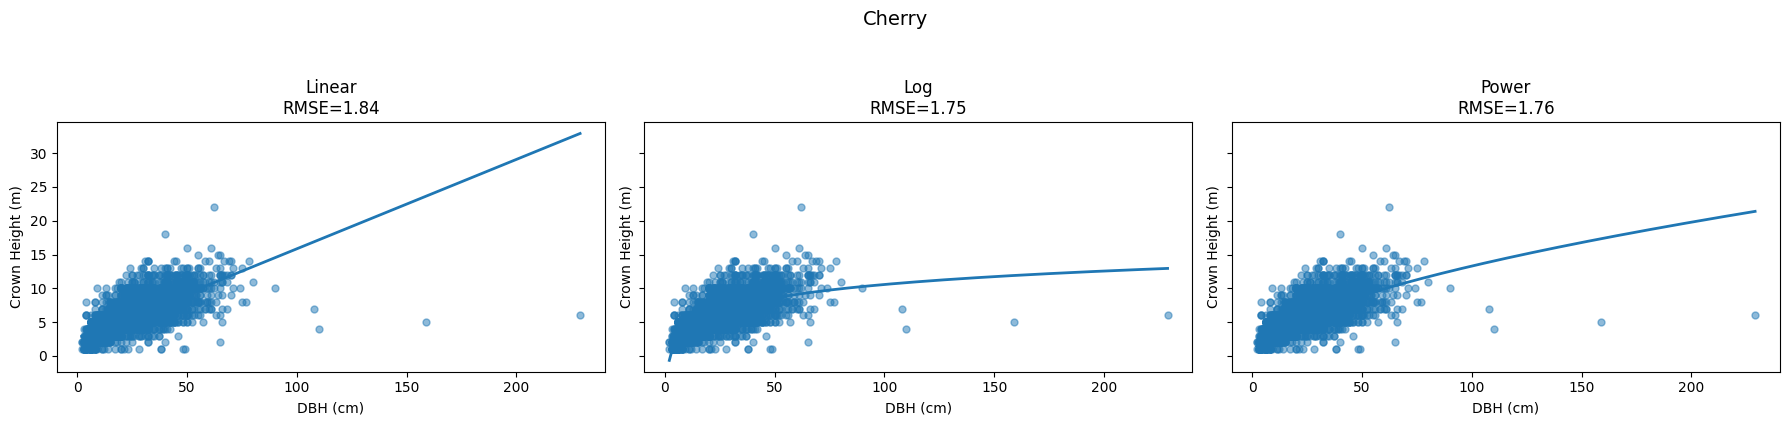

Species: Cherry
Linear: RMSE = 1.84
Log:    RMSE = 1.75
Power:  RMSE = 1.76
------------------------------------------------------------


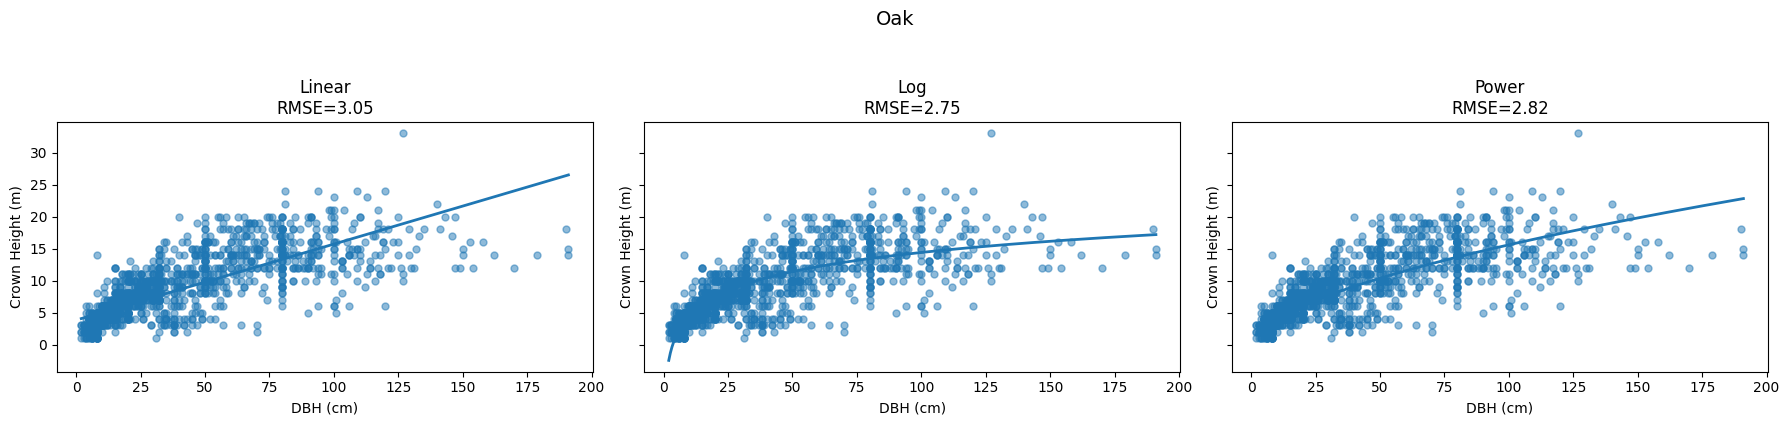

Species: Oak
Linear: RMSE = 3.05
Log:    RMSE = 2.75
Power:  RMSE = 2.82
------------------------------------------------------------


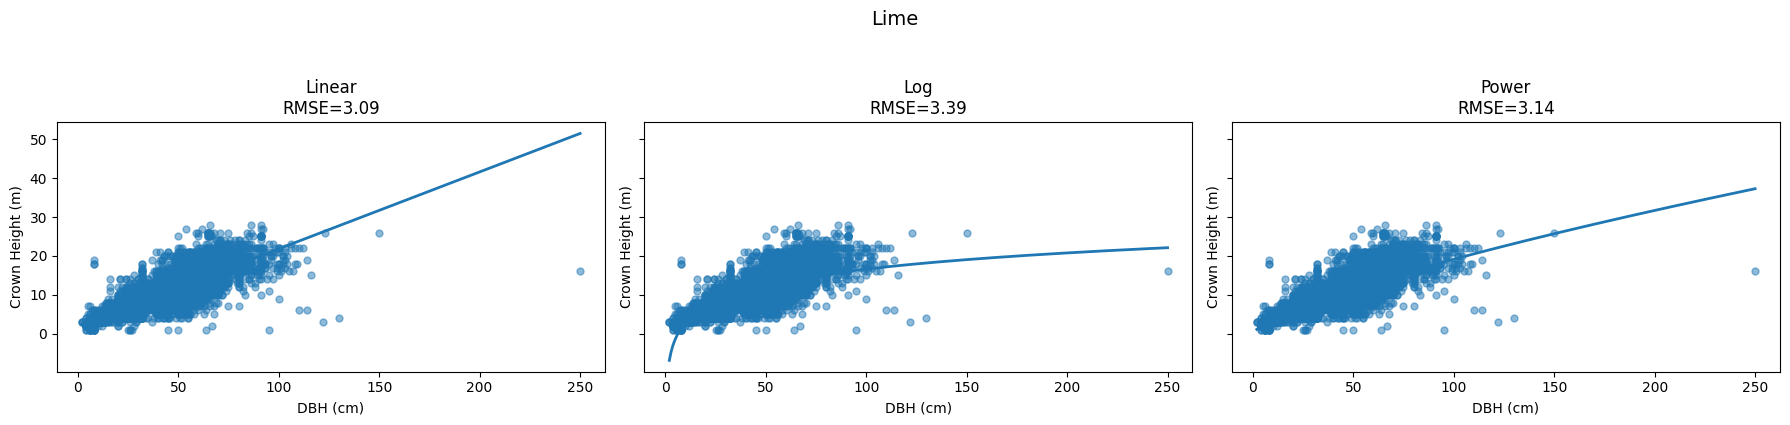

Species: Lime
Linear: RMSE = 3.09
Log:    RMSE = 3.39
Power:  RMSE = 3.14
------------------------------------------------------------


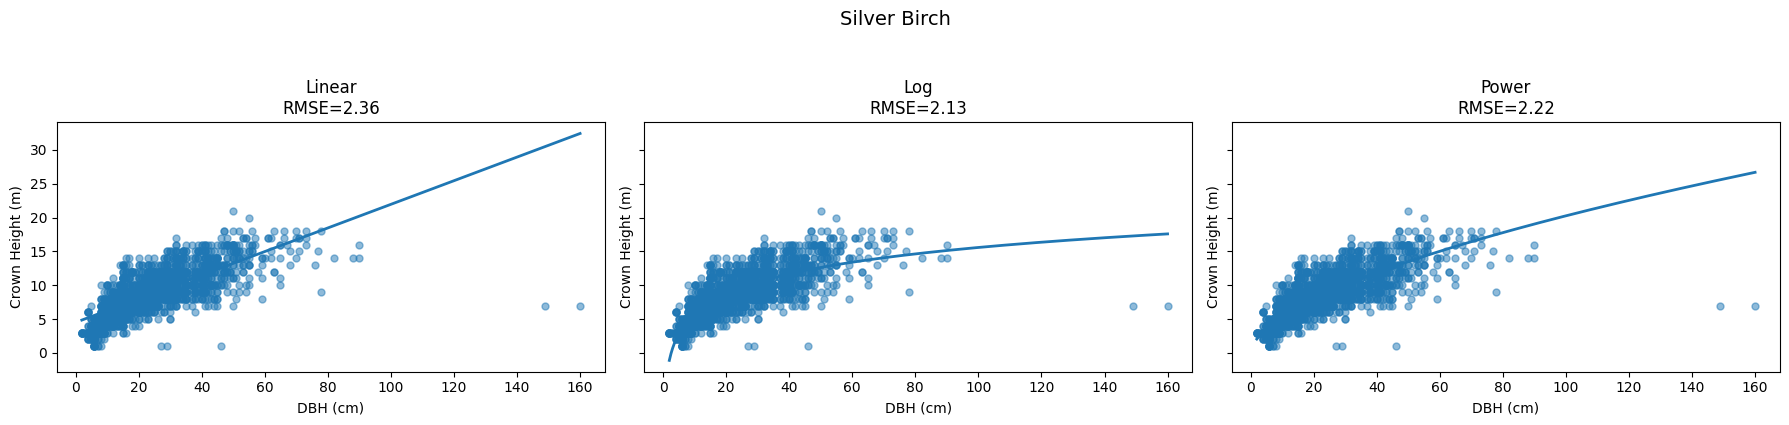

Species: Silver Birch
Linear: RMSE = 2.36
Log:    RMSE = 2.13
Power:  RMSE = 2.22
------------------------------------------------------------


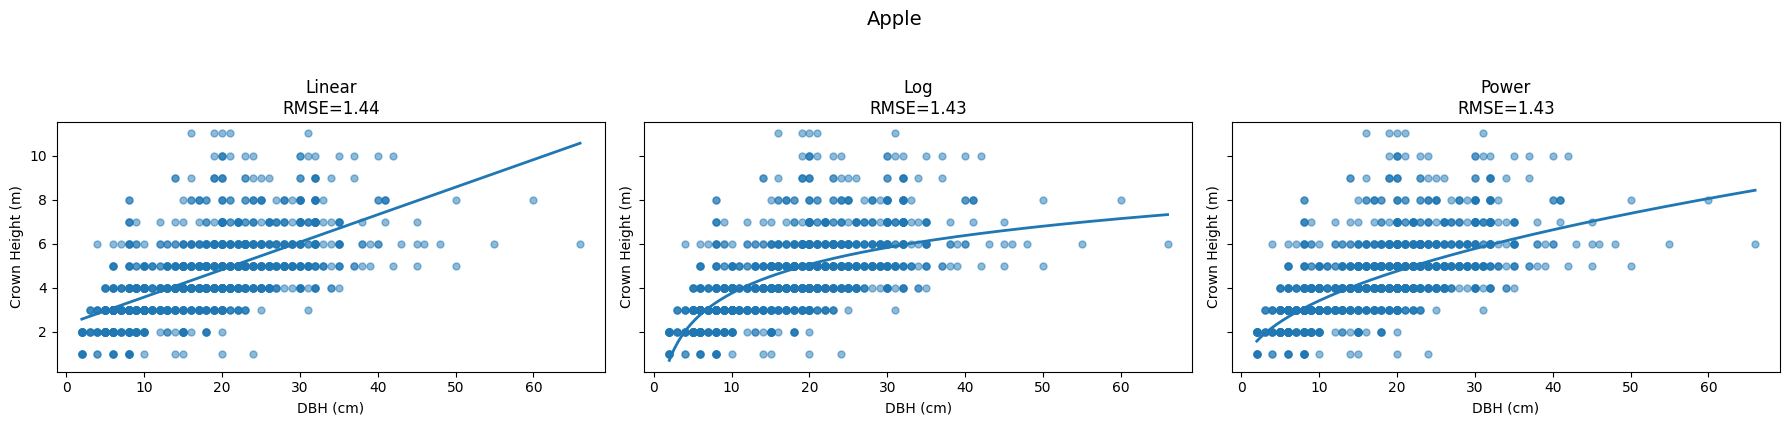

Species: Apple
Linear: RMSE = 1.44
Log:    RMSE = 1.43
Power:  RMSE = 1.43
------------------------------------------------------------


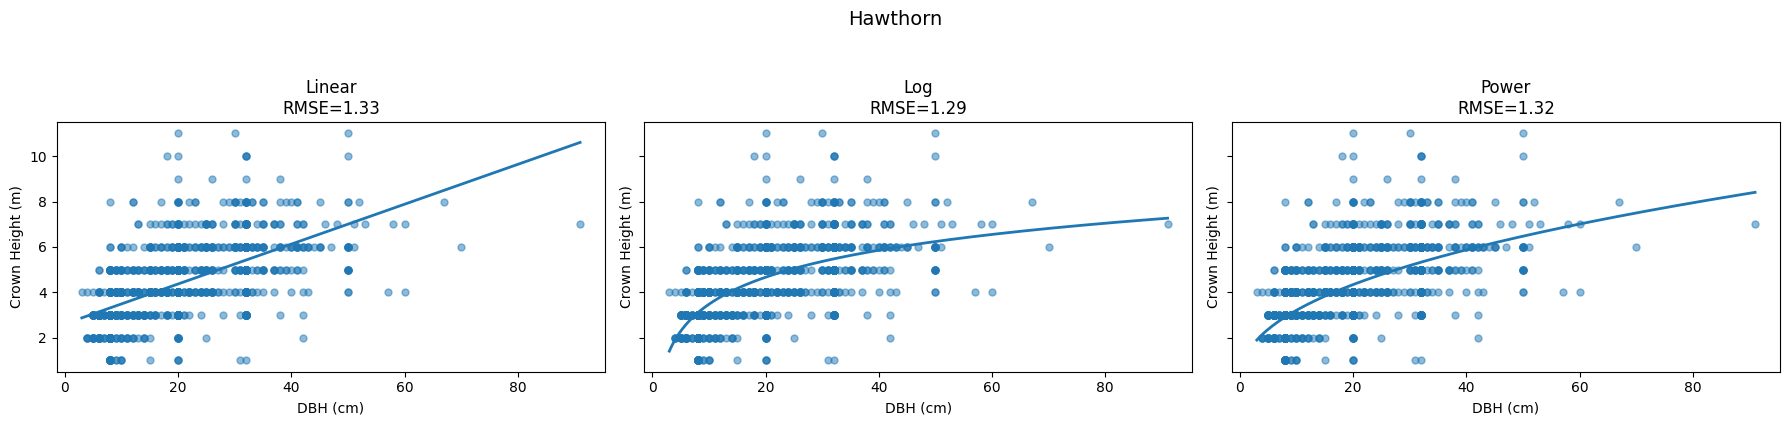

Species: Hawthorn
Linear: RMSE = 1.33
Log:    RMSE = 1.29
Power:  RMSE = 1.32
------------------------------------------------------------


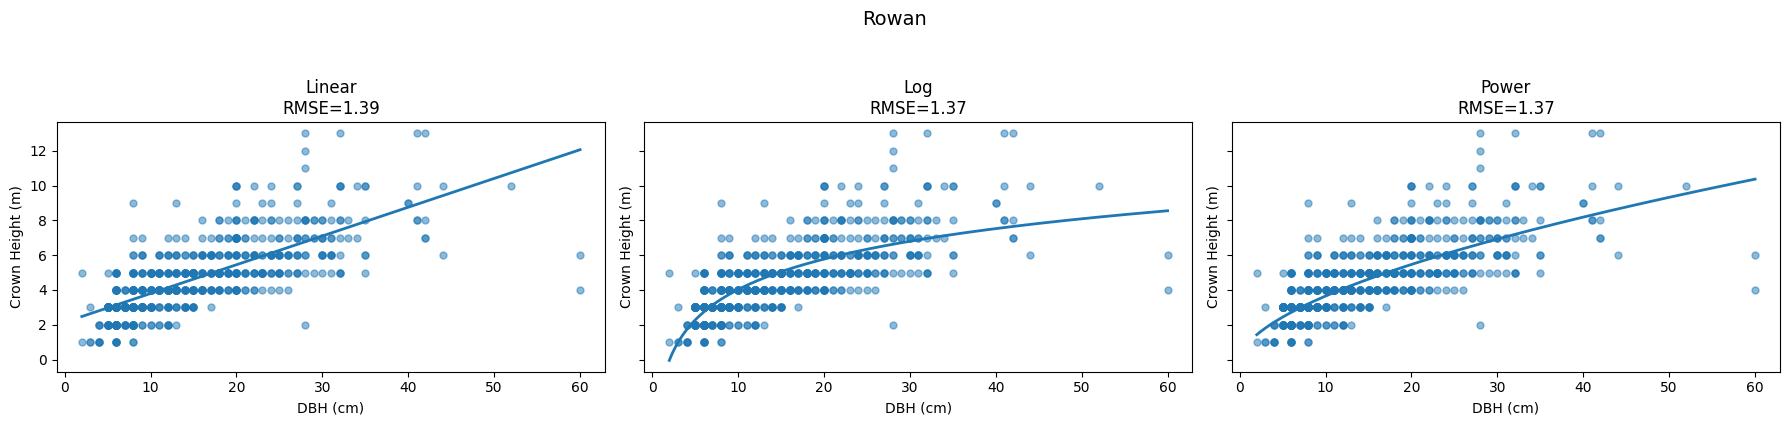

Species: Rowan
Linear: RMSE = 1.39
Log:    RMSE = 1.37
Power:  RMSE = 1.37
------------------------------------------------------------


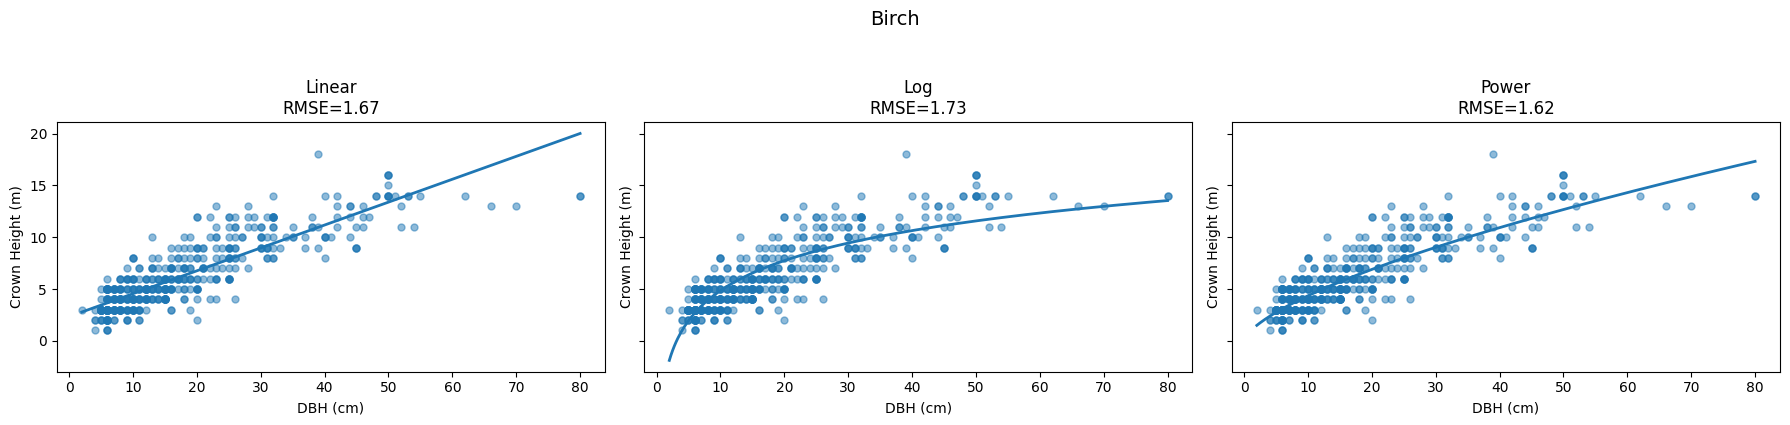

Species: Birch
Linear: RMSE = 1.67
Log:    RMSE = 1.73
Power:  RMSE = 1.62
------------------------------------------------------------


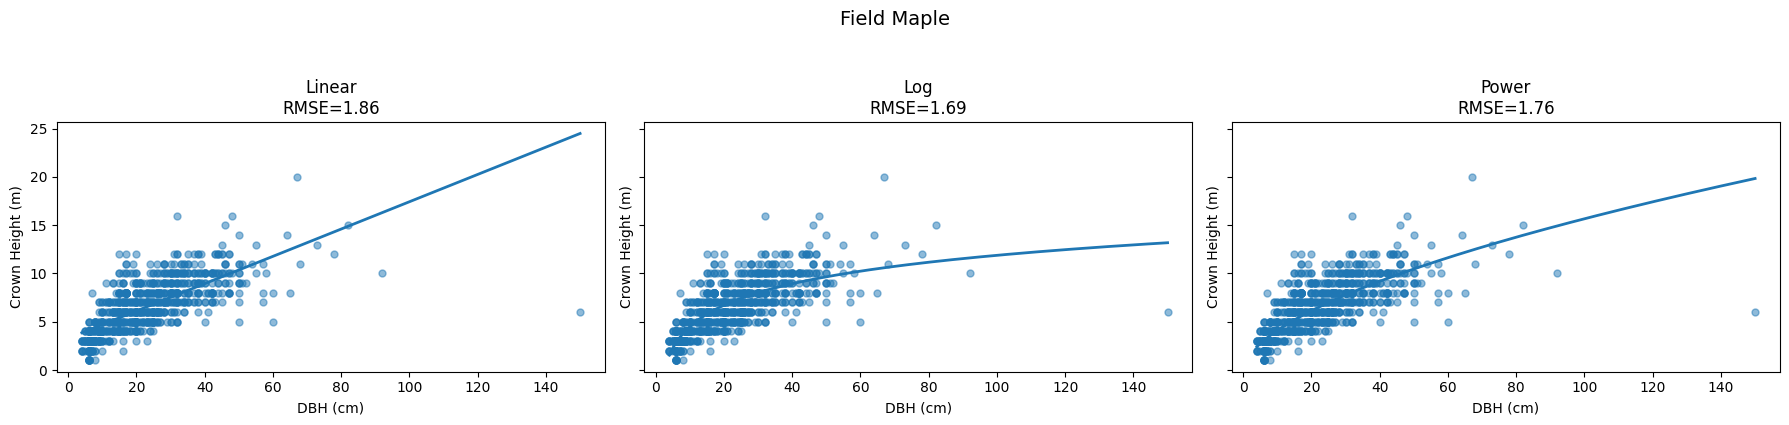

Species: Field Maple
Linear: RMSE = 1.86
Log:    RMSE = 1.69
Power:  RMSE = 1.76
------------------------------------------------------------


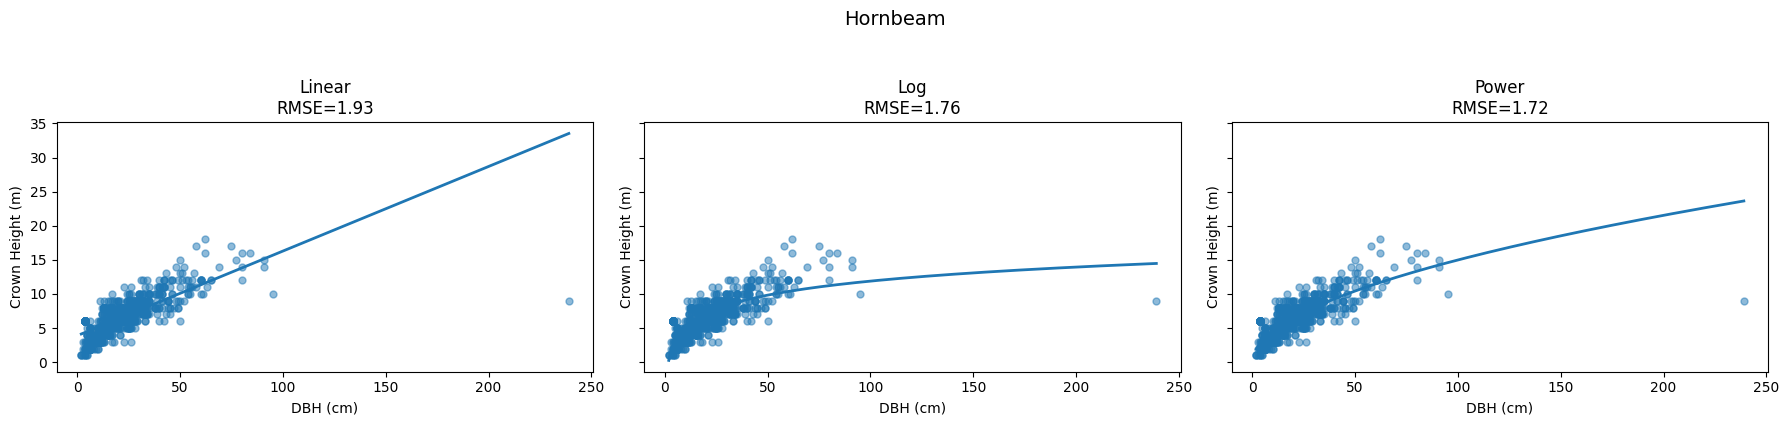

Species: Hornbeam
Linear: RMSE = 1.93
Log:    RMSE = 1.76
Power:  RMSE = 1.72
------------------------------------------------------------


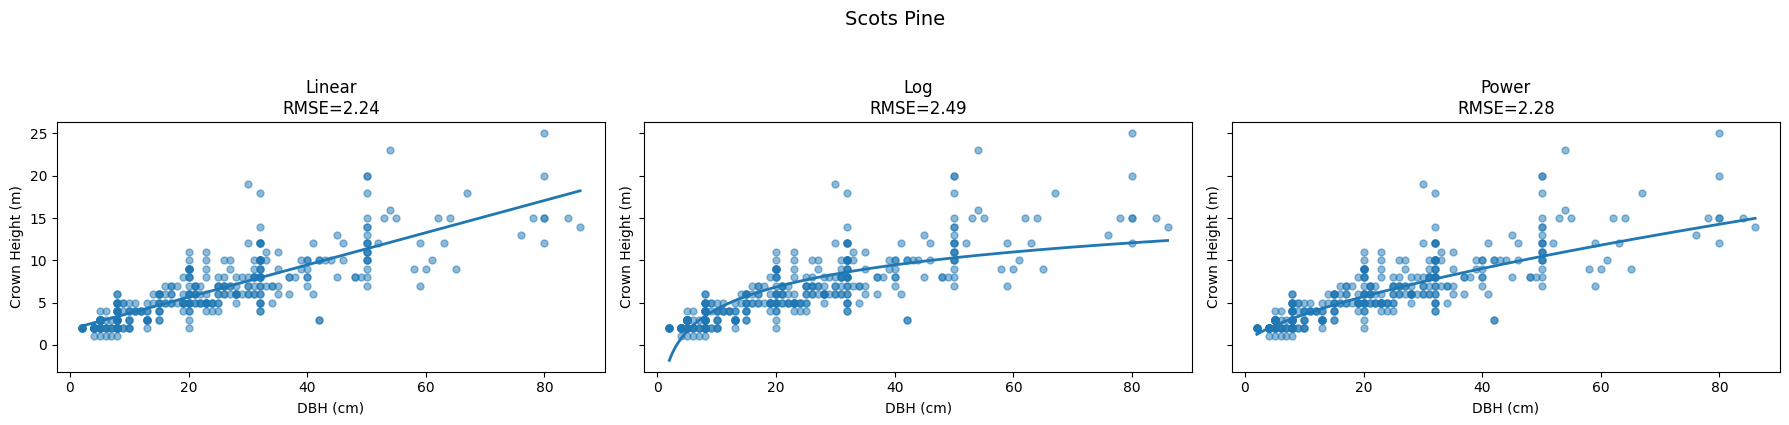

Species: Scots Pine
Linear: RMSE = 2.24
Log:    RMSE = 2.49
Power:  RMSE = 2.28
------------------------------------------------------------


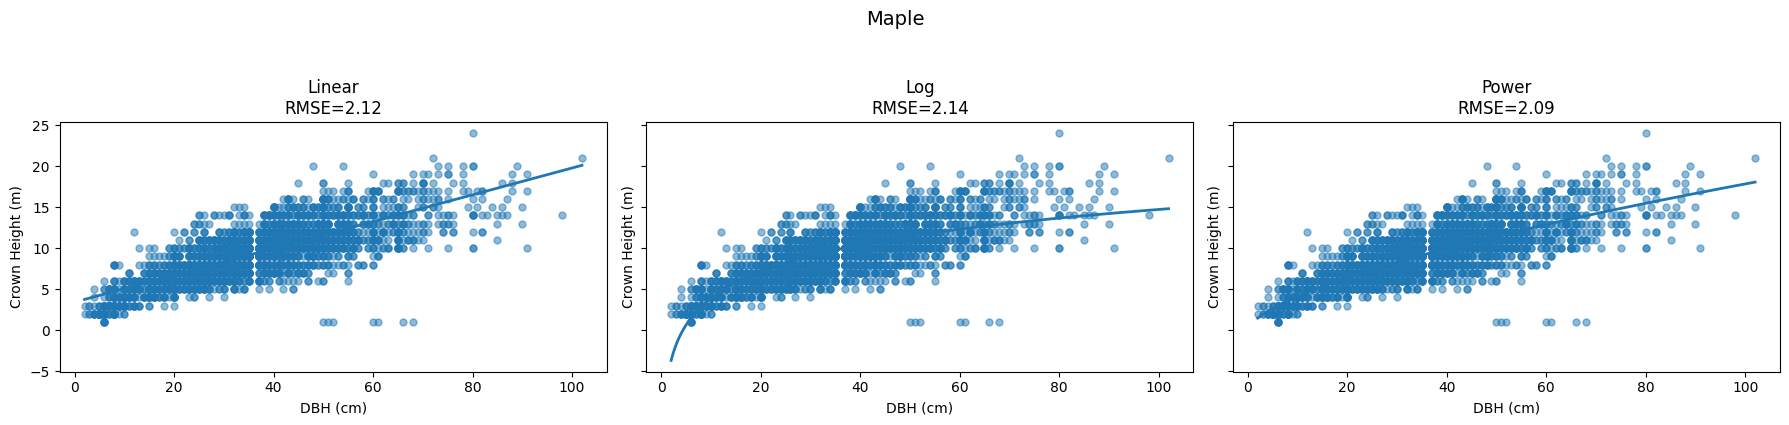

Species: Maple
Linear: RMSE = 2.12
Log:    RMSE = 2.14
Power:  RMSE = 2.09
------------------------------------------------------------


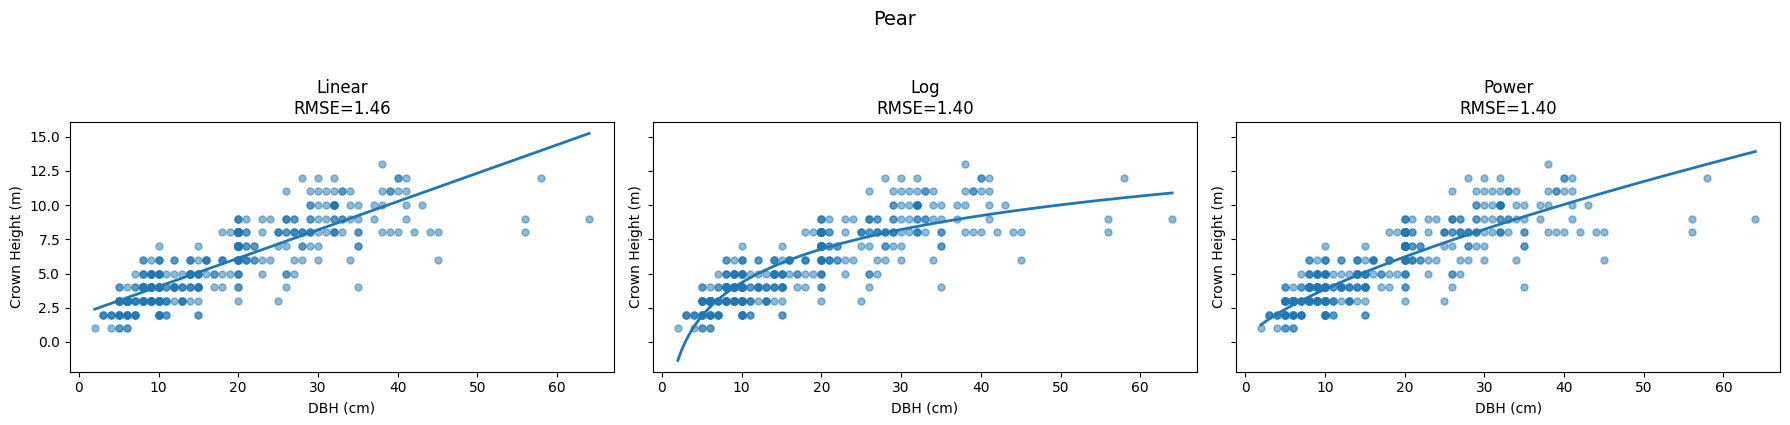

Species: Pear
Linear: RMSE = 1.46
Log:    RMSE = 1.40
Power:  RMSE = 1.40
------------------------------------------------------------


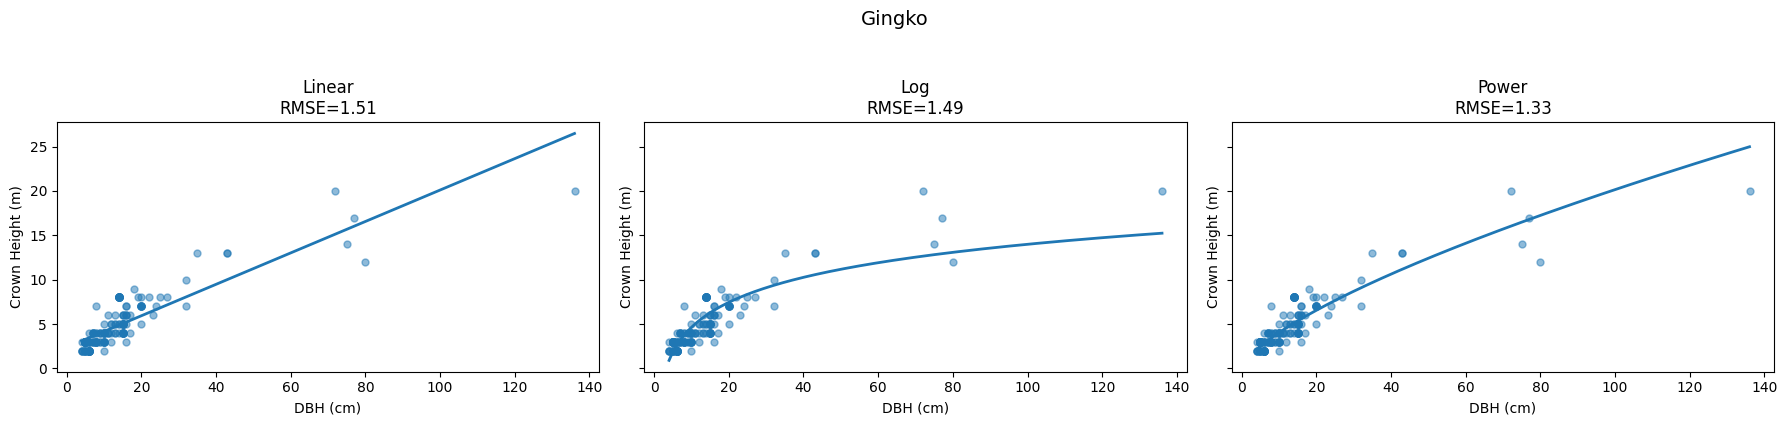

Species: Gingko
Linear: RMSE = 1.51
Log:    RMSE = 1.49
Power:  RMSE = 1.33
------------------------------------------------------------


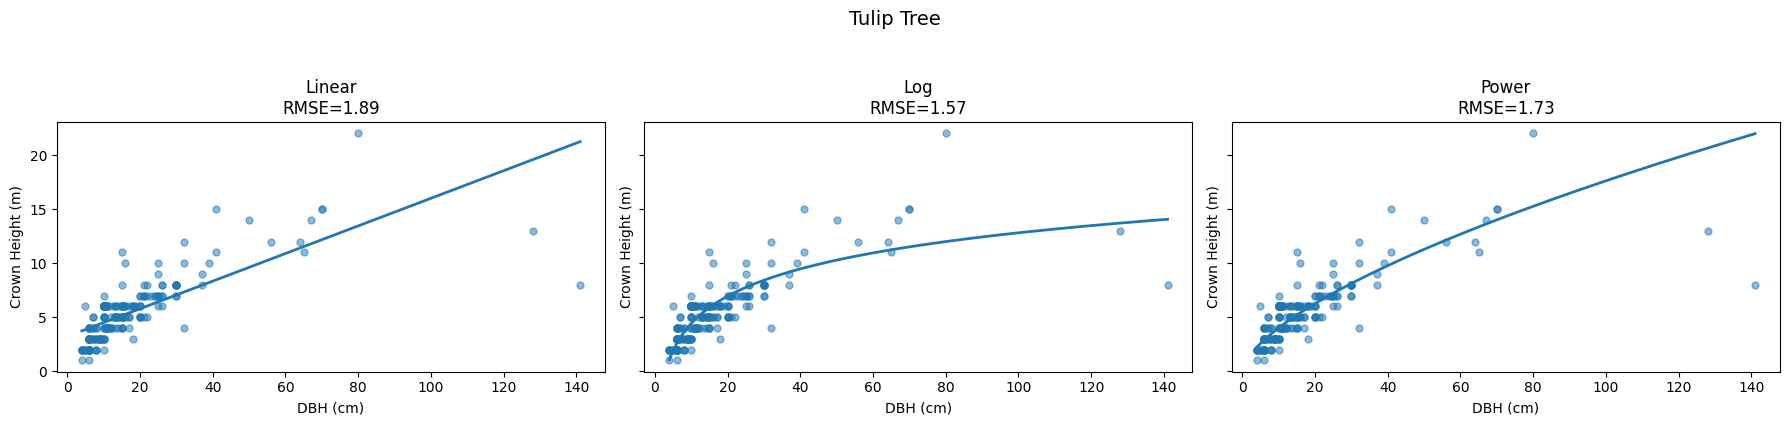

Species: Tulip Tree
Linear: RMSE = 1.89
Log:    RMSE = 1.57
Power:  RMSE = 1.73
------------------------------------------------------------


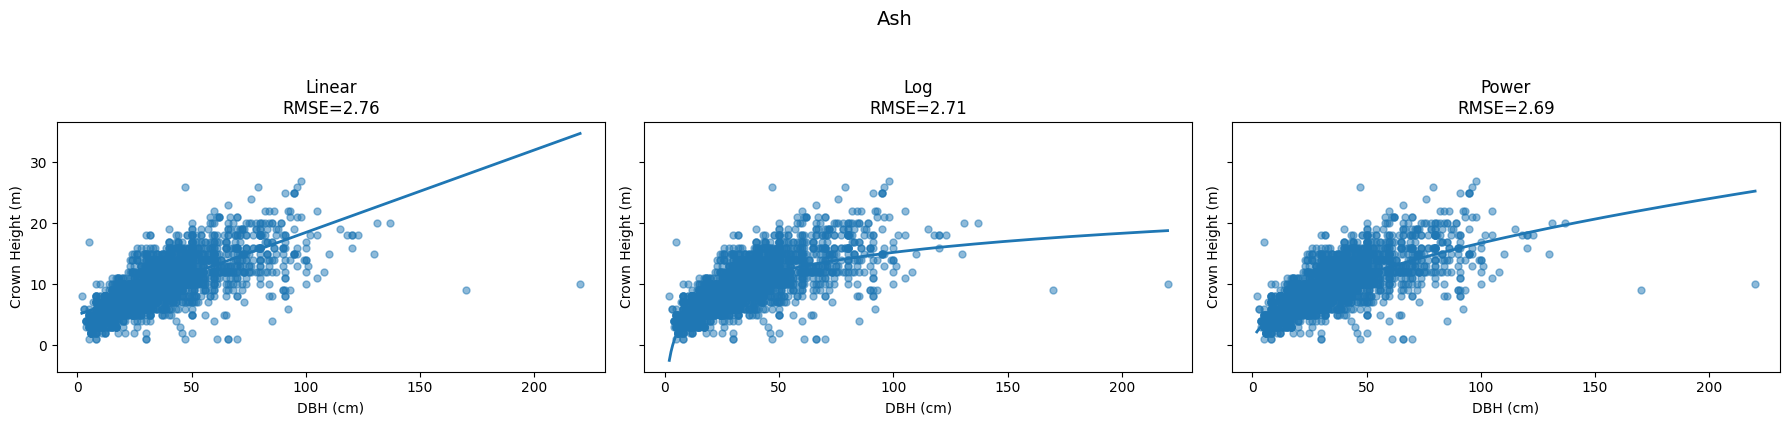

Species: Ash
Linear: RMSE = 2.76
Log:    RMSE = 2.71
Power:  RMSE = 2.69
------------------------------------------------------------


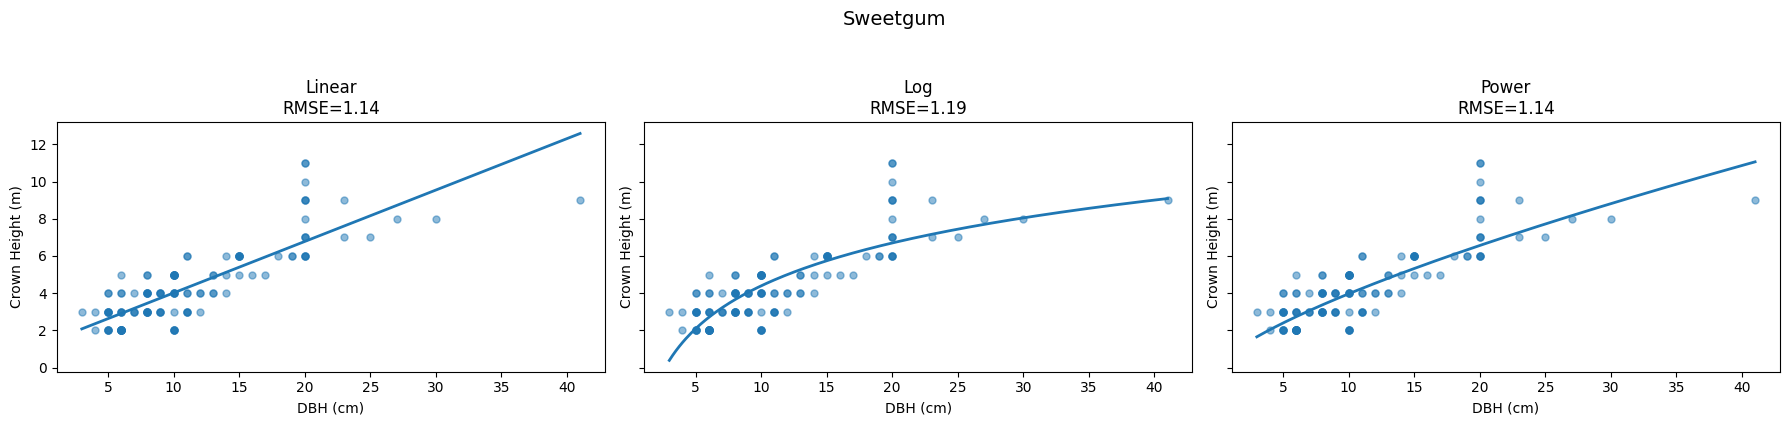

Species: Sweetgum
Linear: RMSE = 1.14
Log:    RMSE = 1.19
Power:  RMSE = 1.14
------------------------------------------------------------


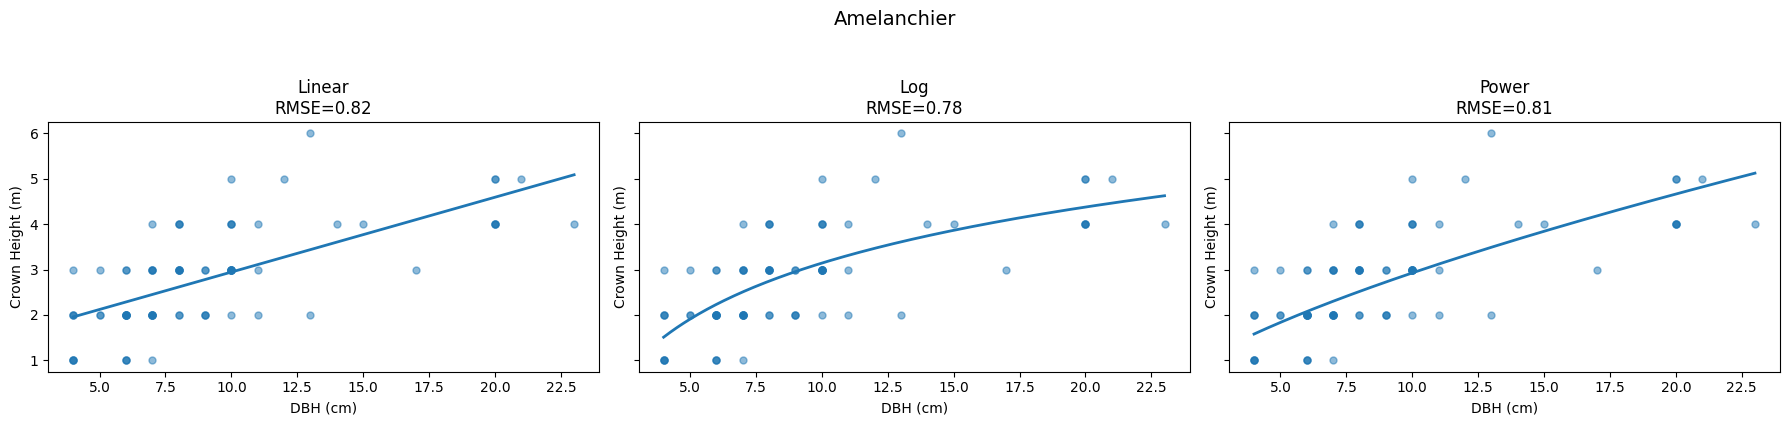

Species: Amelanchier
Linear: RMSE = 0.82
Log:    RMSE = 0.78
Power:  RMSE = 0.81
------------------------------------------------------------


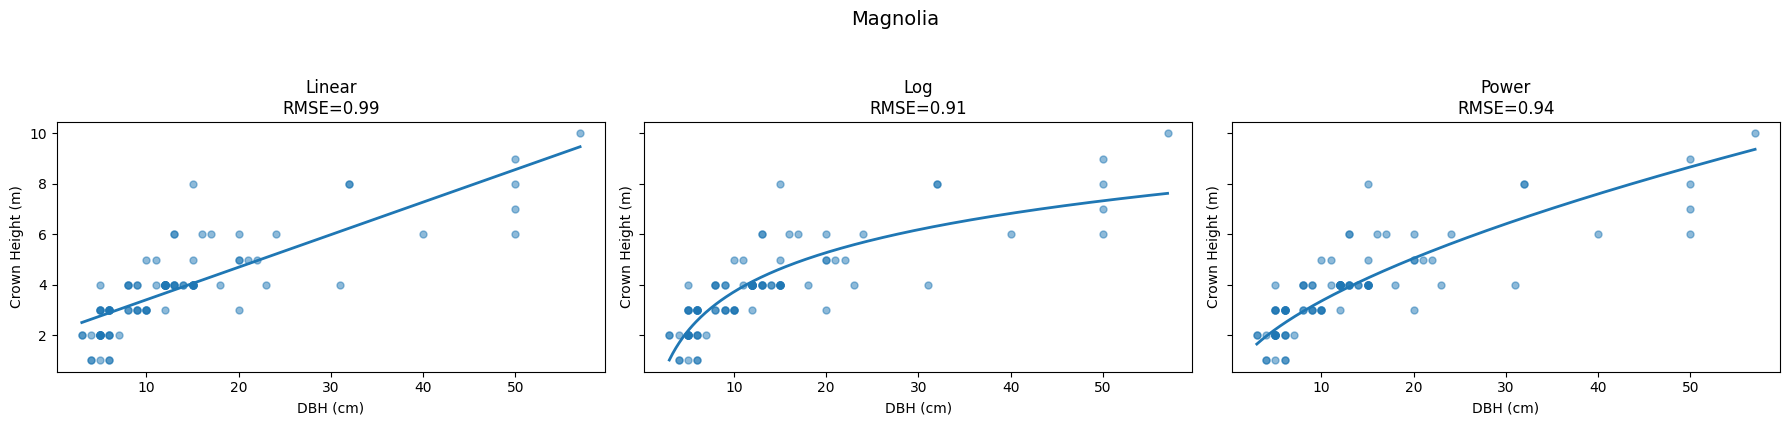

Species: Magnolia
Linear: RMSE = 0.99
Log:    RMSE = 0.91
Power:  RMSE = 0.94
------------------------------------------------------------


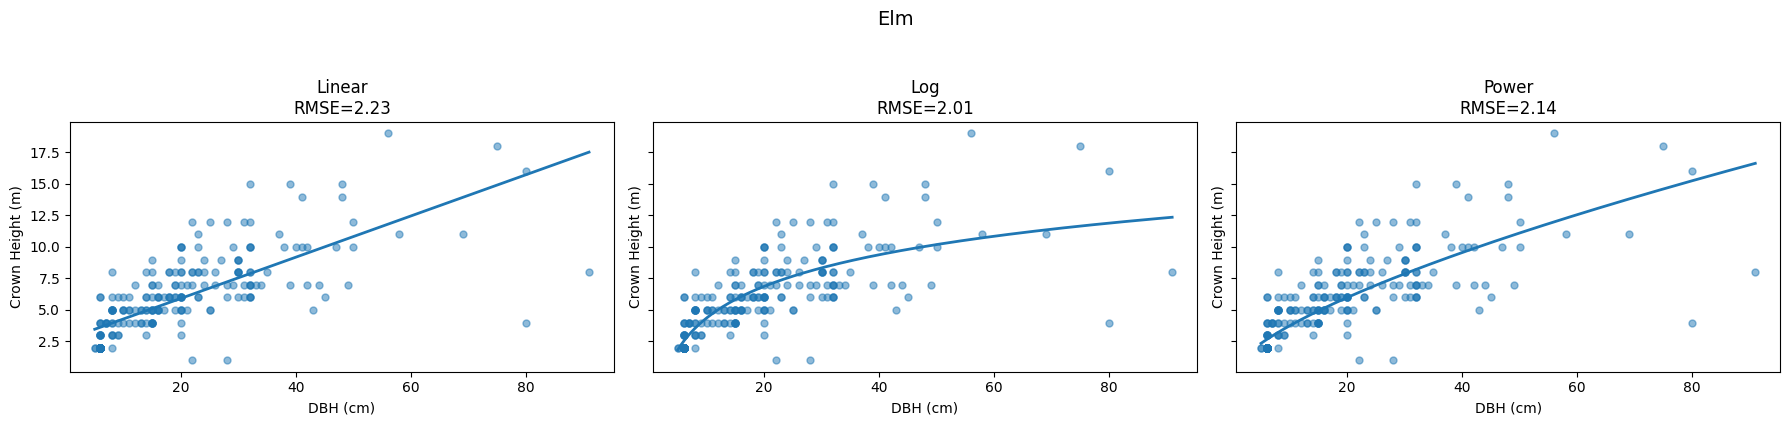

Species: Elm
Linear: RMSE = 2.23
Log:    RMSE = 2.01
Power:  RMSE = 2.14
------------------------------------------------------------


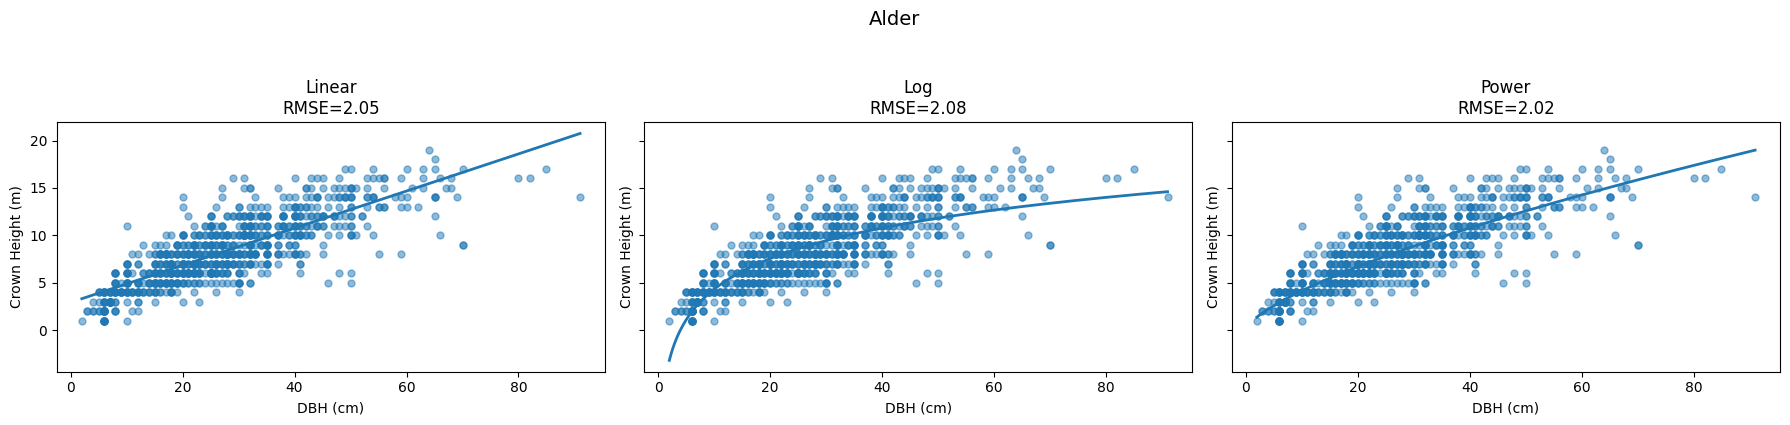

Species: Alder
Linear: RMSE = 2.05
Log:    RMSE = 2.08
Power:  RMSE = 2.02
------------------------------------------------------------


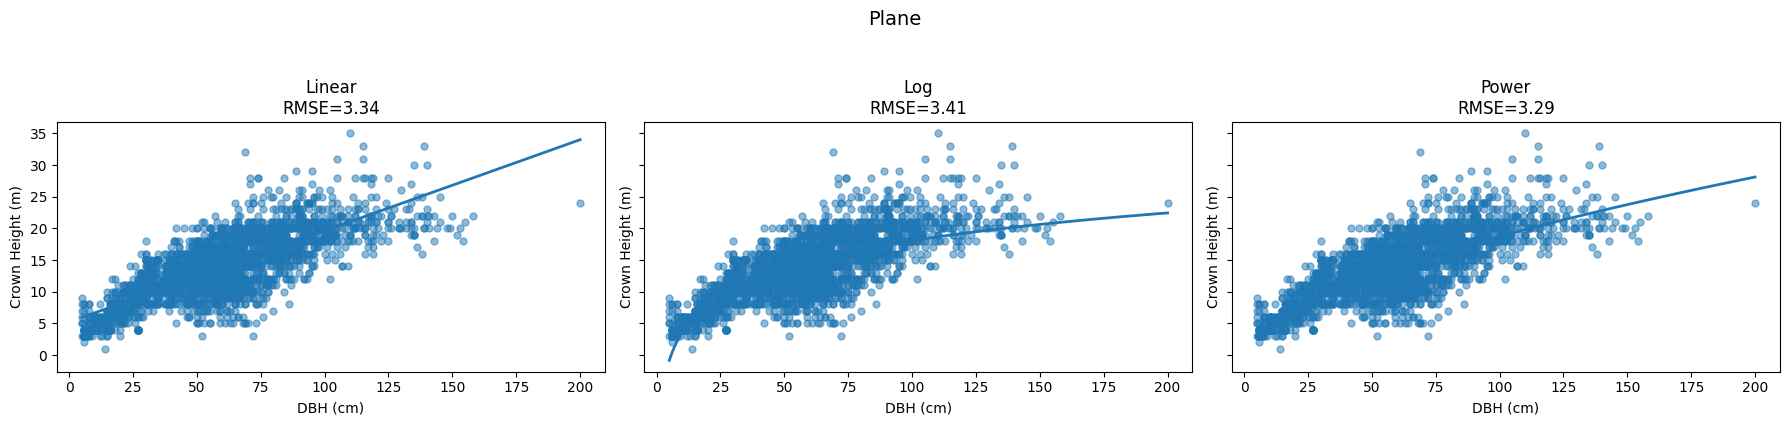

Species: Plane
Linear: RMSE = 3.34
Log:    RMSE = 3.41
Power:  RMSE = 3.29
------------------------------------------------------------


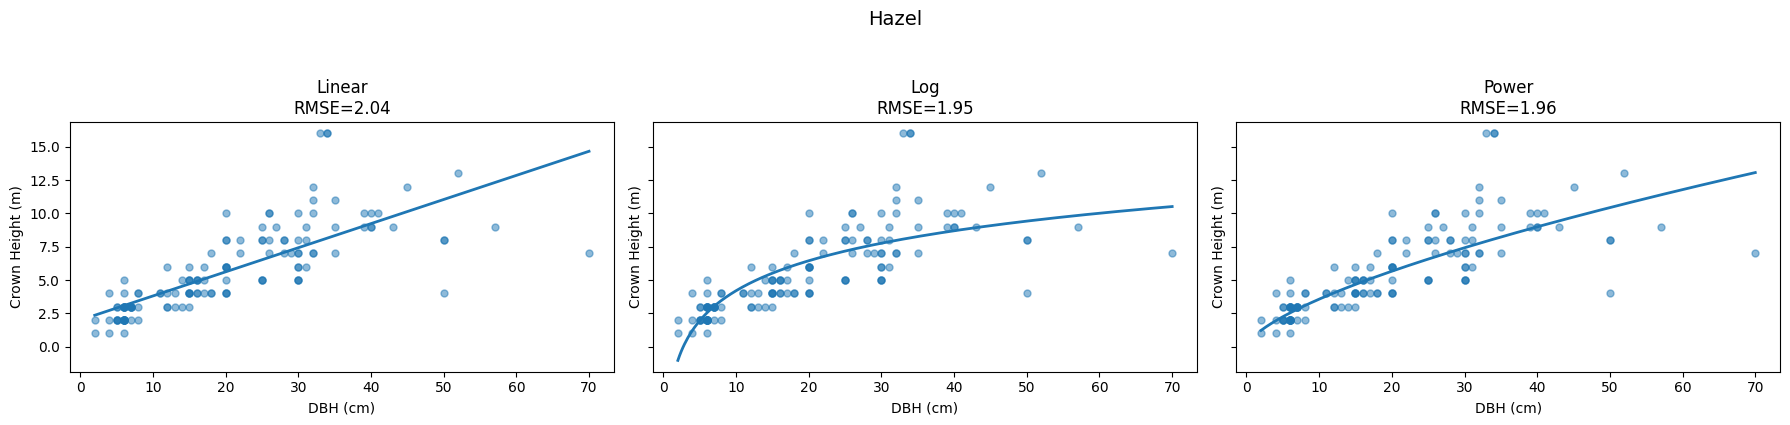

Species: Hazel
Linear: RMSE = 2.04
Log:    RMSE = 1.95
Power:  RMSE = 1.96
------------------------------------------------------------


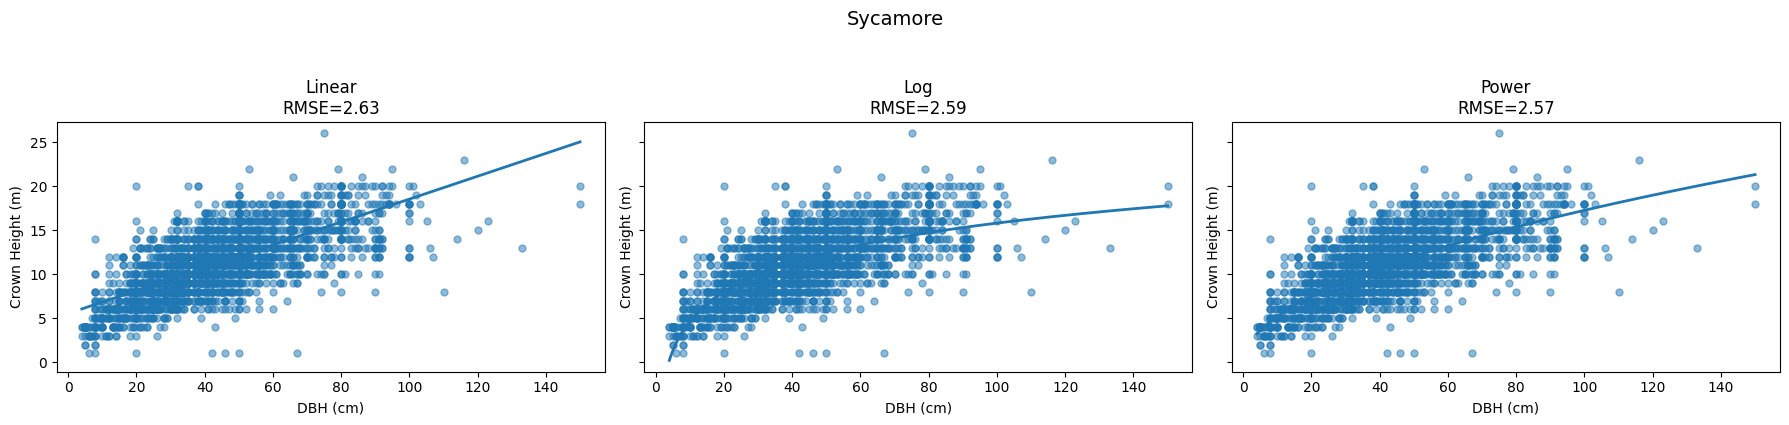

Species: Sycamore
Linear: RMSE = 2.63
Log:    RMSE = 2.59
Power:  RMSE = 2.57
------------------------------------------------------------


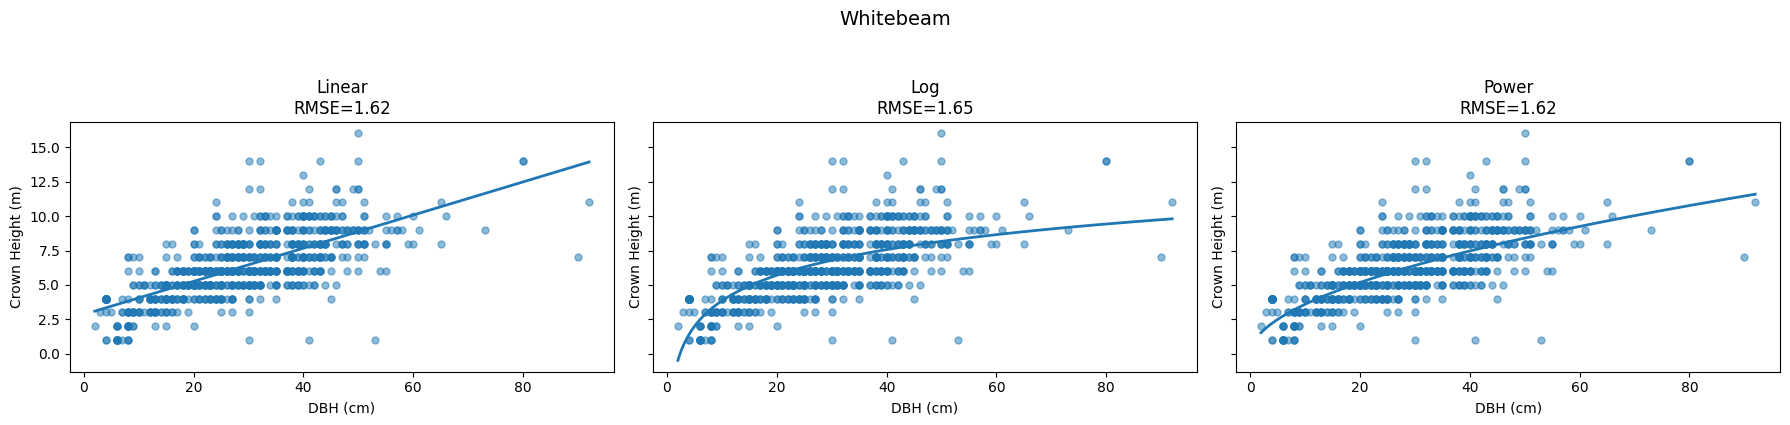

Species: Whitebeam
Linear: RMSE = 1.62
Log:    RMSE = 1.65
Power:  RMSE = 1.62
------------------------------------------------------------


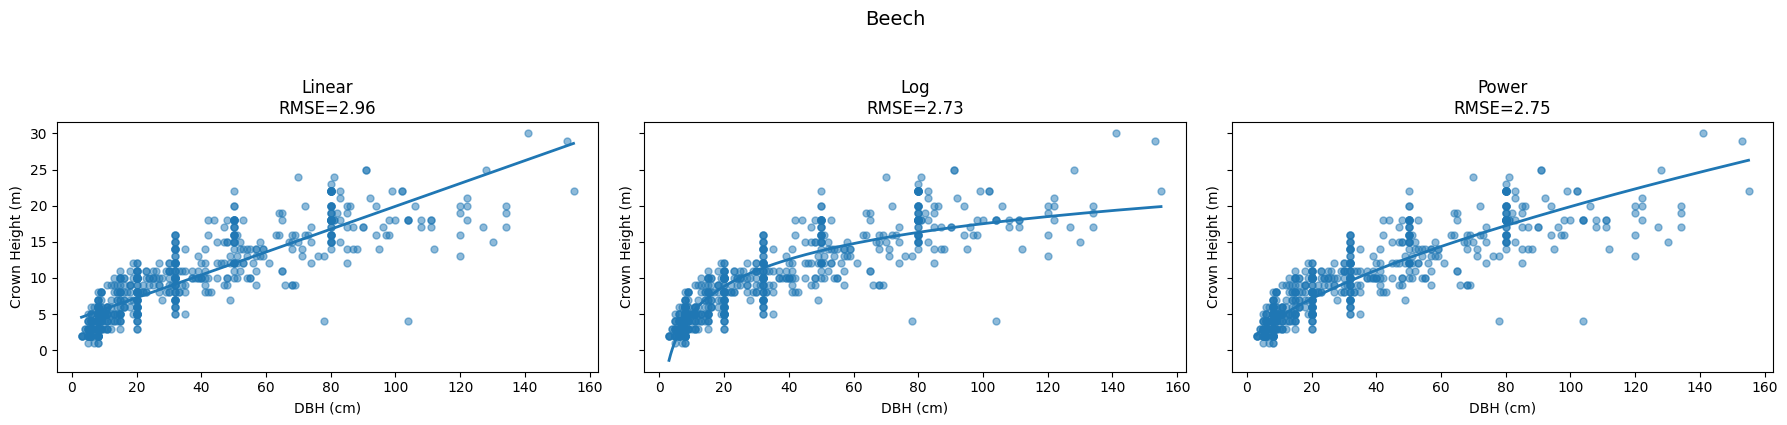

Species: Beech
Linear: RMSE = 2.96
Log:    RMSE = 2.73
Power:  RMSE = 2.75
------------------------------------------------------------


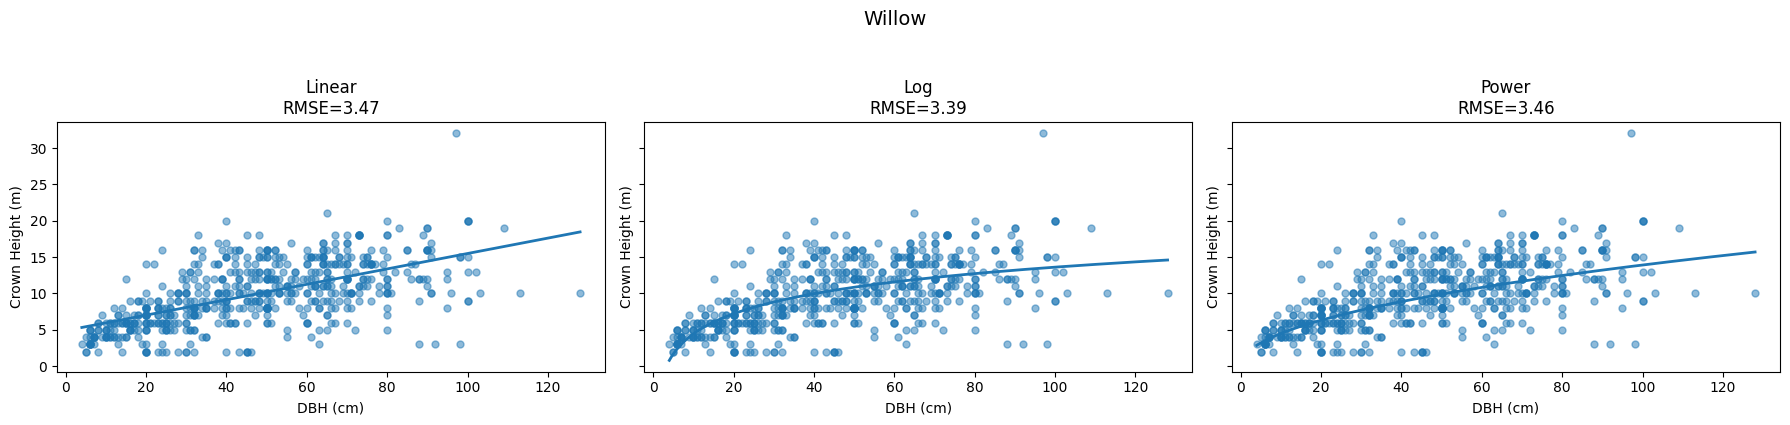

Species: Willow
Linear: RMSE = 3.47
Log:    RMSE = 3.39
Power:  RMSE = 3.46
------------------------------------------------------------


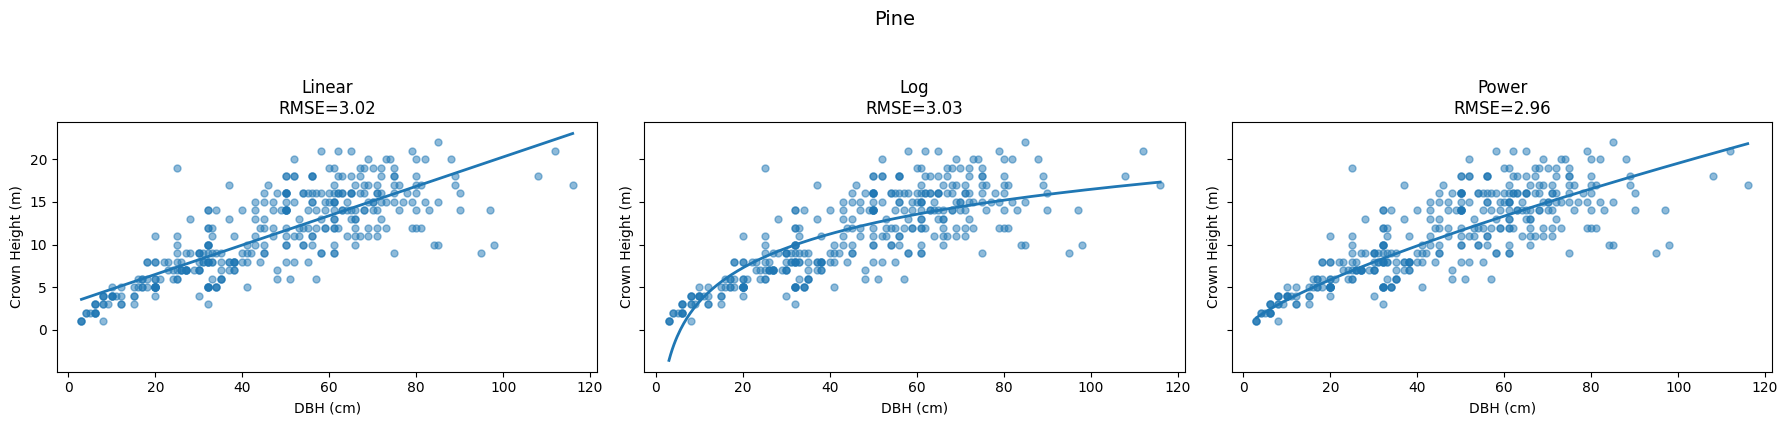

Species: Pine
Linear: RMSE = 3.02
Log:    RMSE = 3.03
Power:  RMSE = 2.96
------------------------------------------------------------


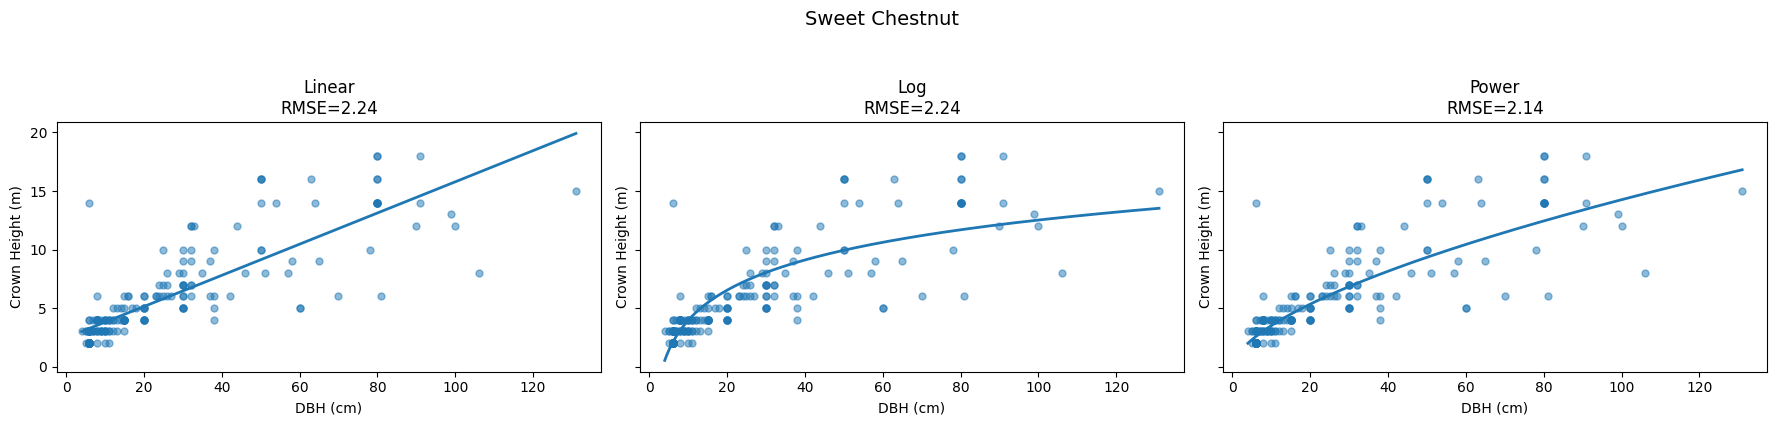

Species: Sweet Chestnut
Linear: RMSE = 2.24
Log:    RMSE = 2.24
Power:  RMSE = 2.14
------------------------------------------------------------


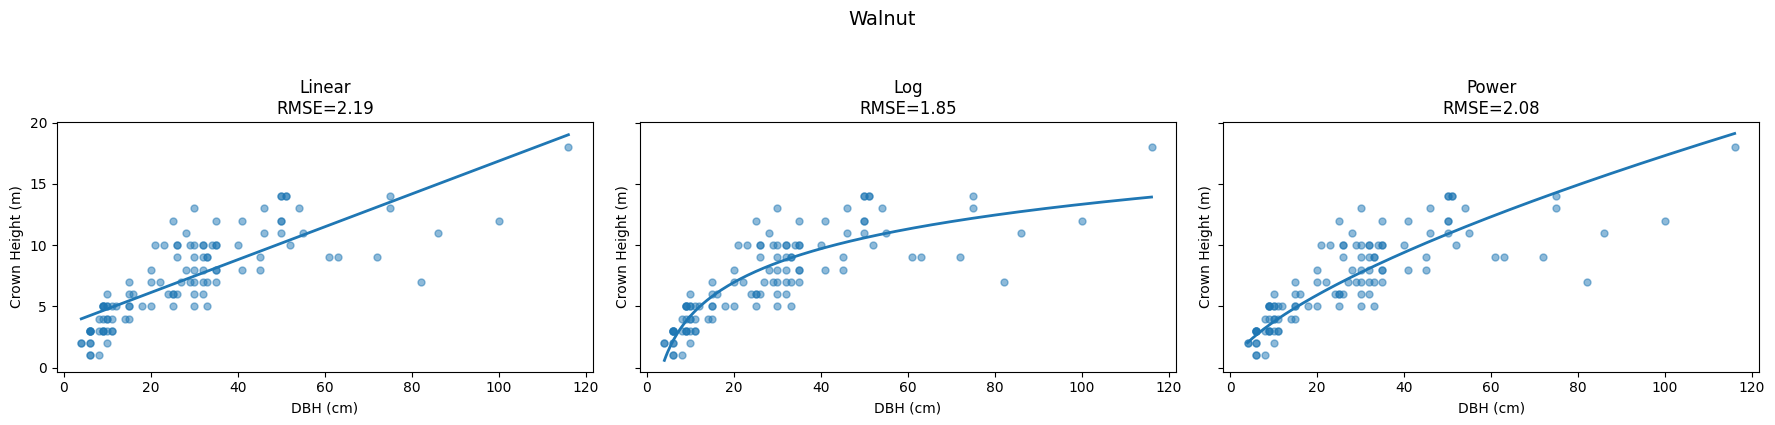

Species: Walnut
Linear: RMSE = 2.19
Log:    RMSE = 1.85
Power:  RMSE = 2.08
------------------------------------------------------------


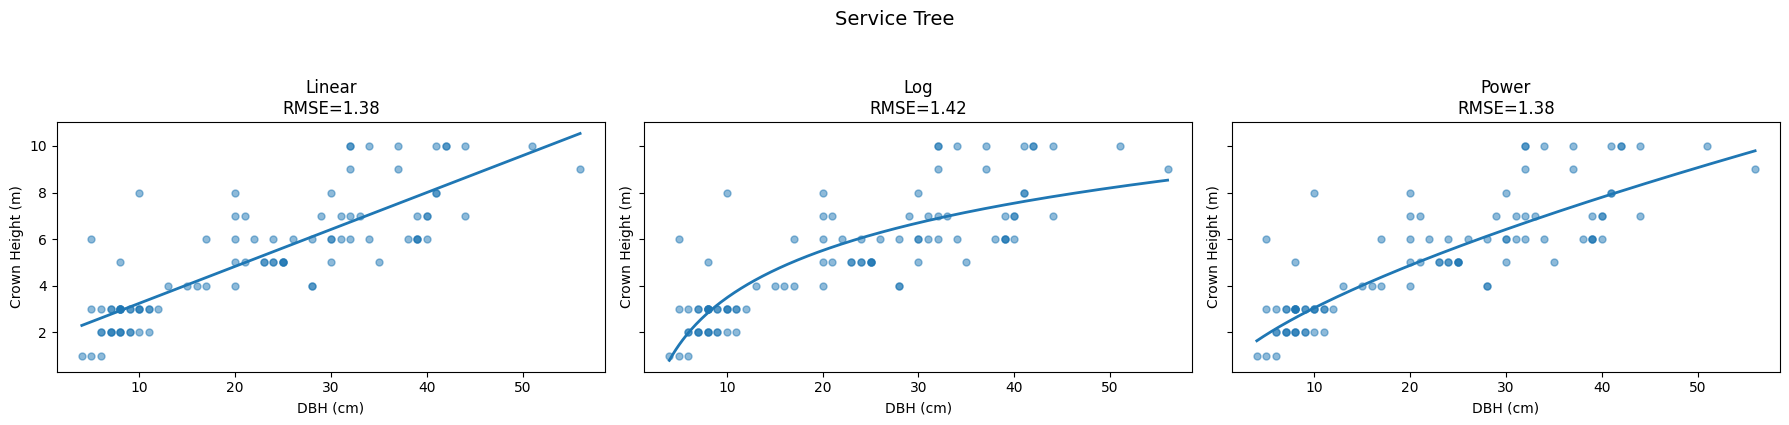

Species: Service Tree
Linear: RMSE = 1.38
Log:    RMSE = 1.42
Power:  RMSE = 1.38
------------------------------------------------------------


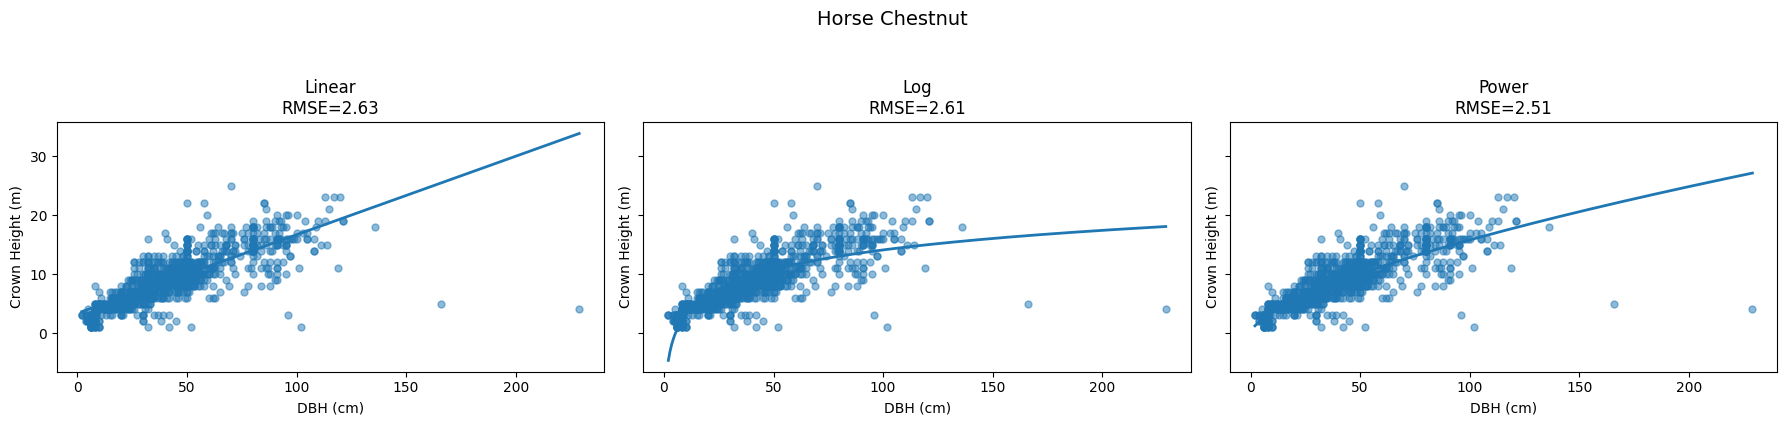

Species: Horse Chestnut
Linear: RMSE = 2.63
Log:    RMSE = 2.61
Power:  RMSE = 2.51
------------------------------------------------------------


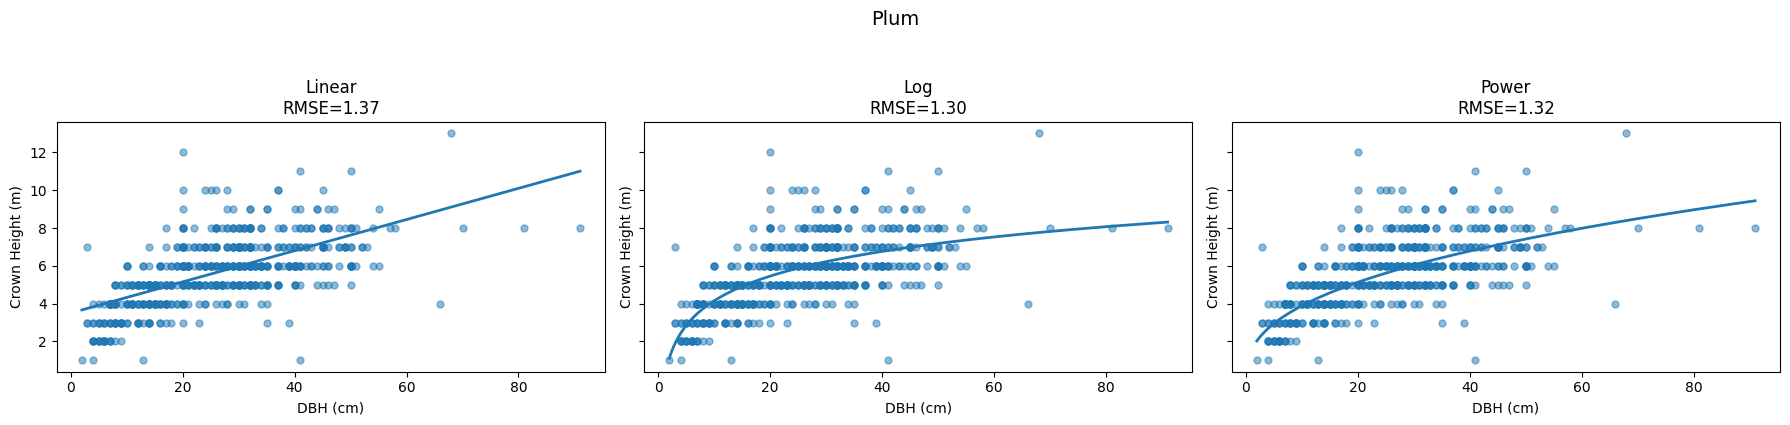

Species: Plum
Linear: RMSE = 1.37
Log:    RMSE = 1.30
Power:  RMSE = 1.32
------------------------------------------------------------


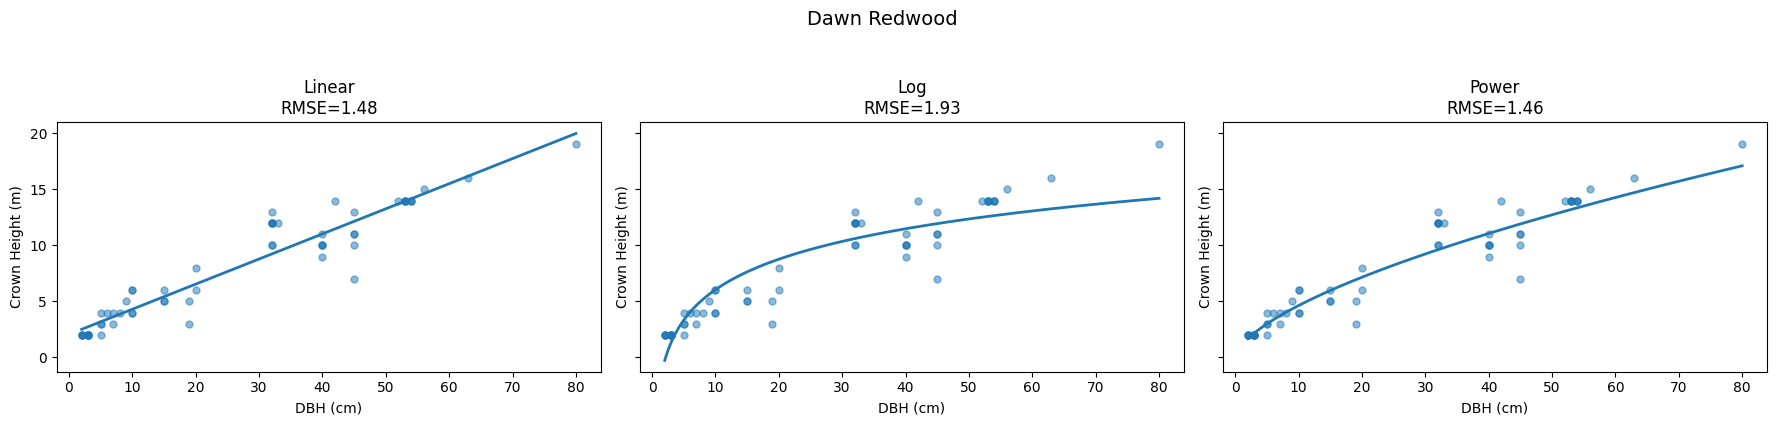

Species: Dawn Redwood
Linear: RMSE = 1.48
Log:    RMSE = 1.93
Power:  RMSE = 1.46
------------------------------------------------------------


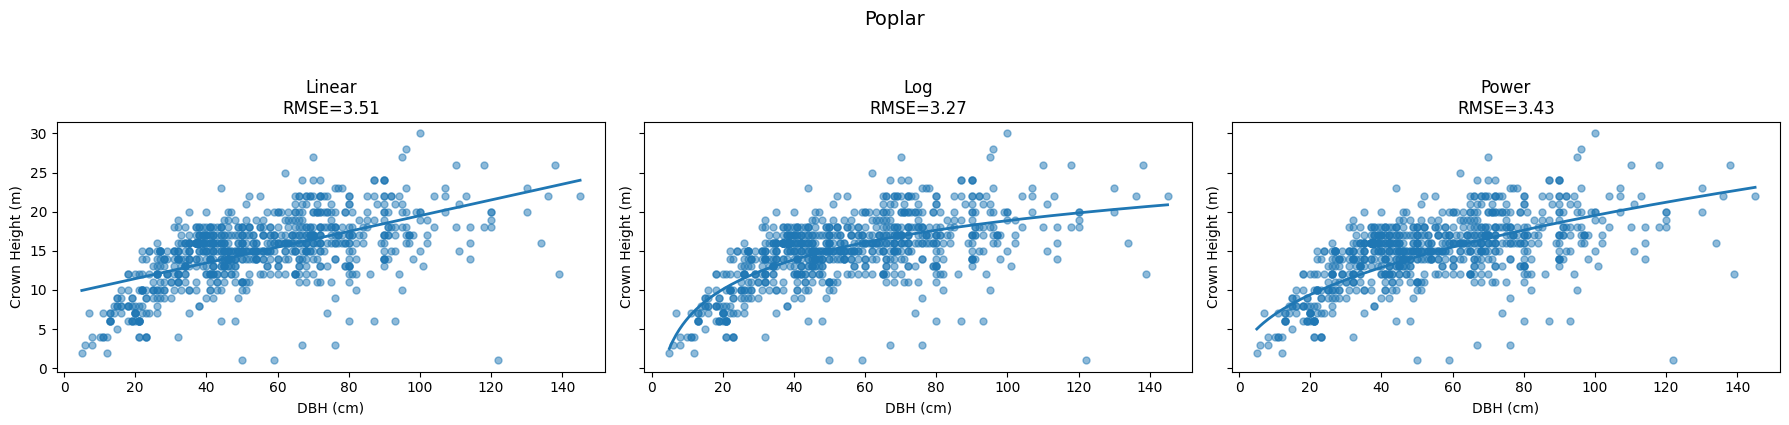

Species: Poplar
Linear: RMSE = 3.51
Log:    RMSE = 3.27
Power:  RMSE = 3.43
------------------------------------------------------------


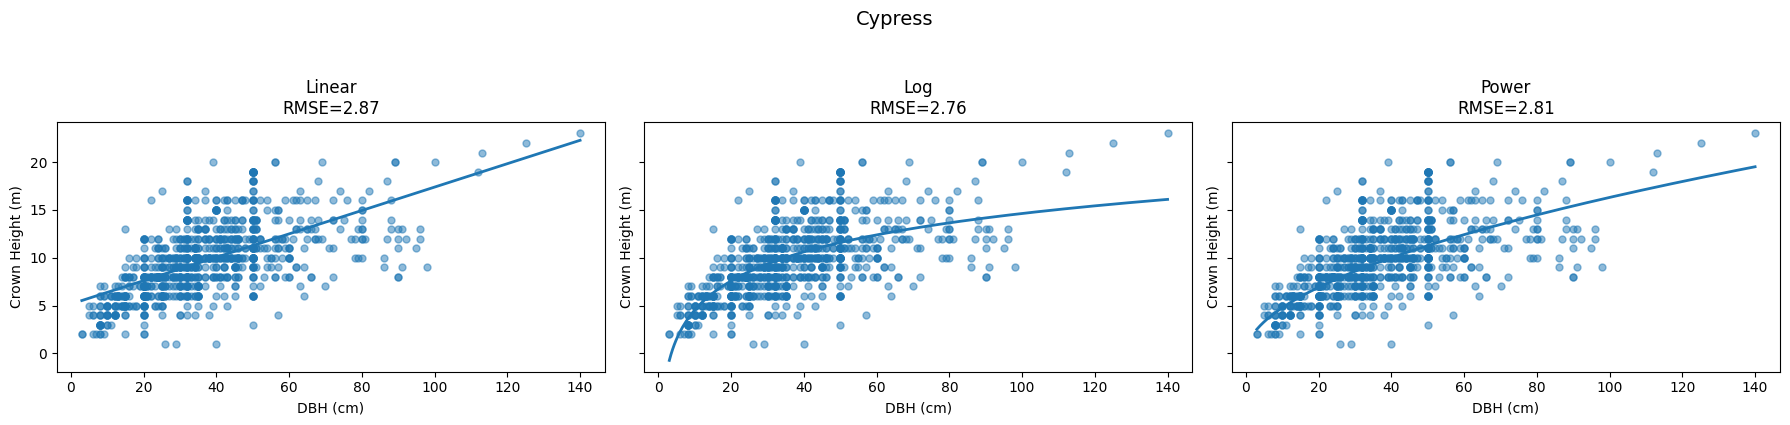

Species: Cypress
Linear: RMSE = 2.87
Log:    RMSE = 2.76
Power:  RMSE = 2.81
------------------------------------------------------------


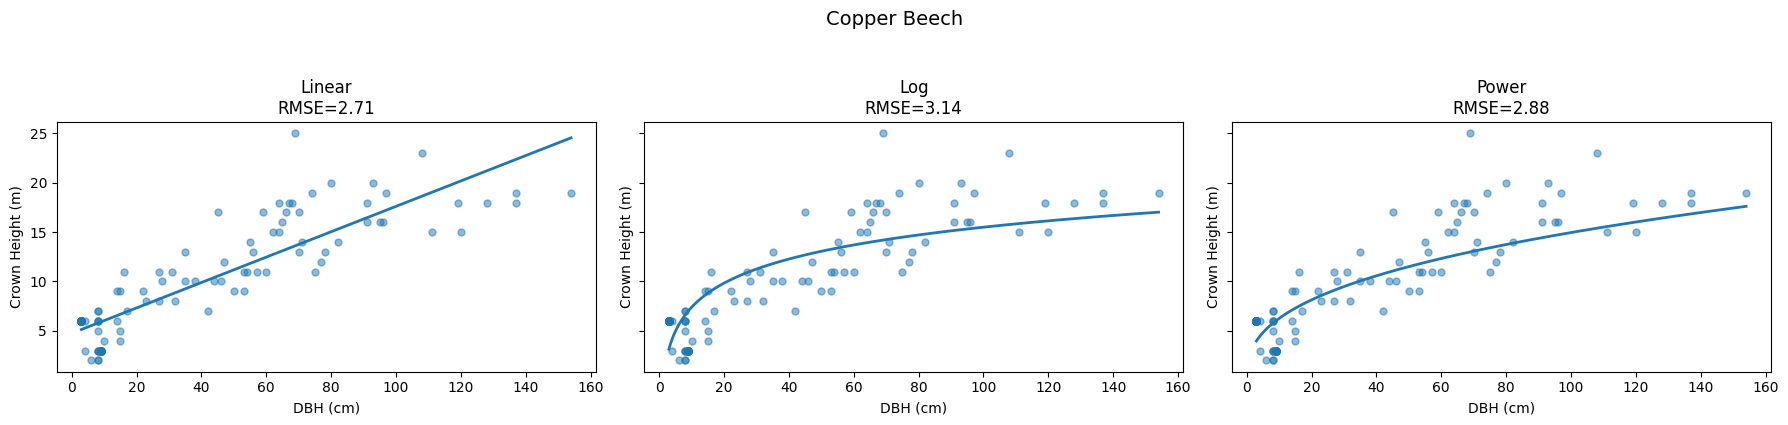

Species: Copper Beech
Linear: RMSE = 2.71
Log:    RMSE = 3.14
Power:  RMSE = 2.88
------------------------------------------------------------


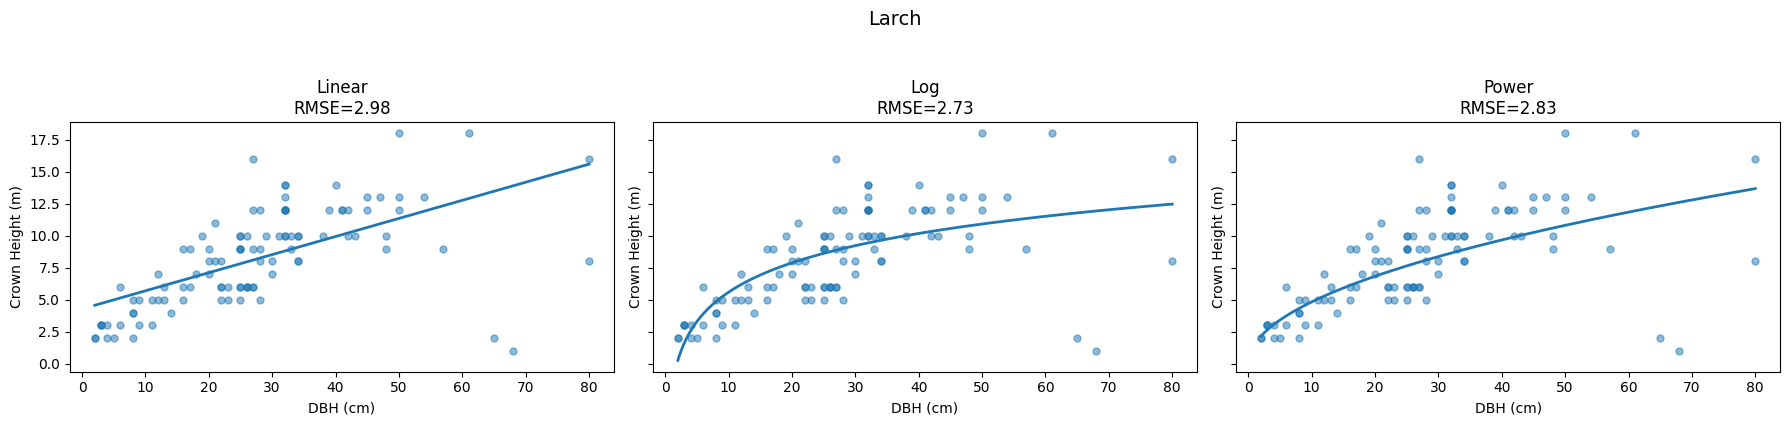

Species: Larch
Linear: RMSE = 2.98
Log:    RMSE = 2.73
Power:  RMSE = 2.83
------------------------------------------------------------


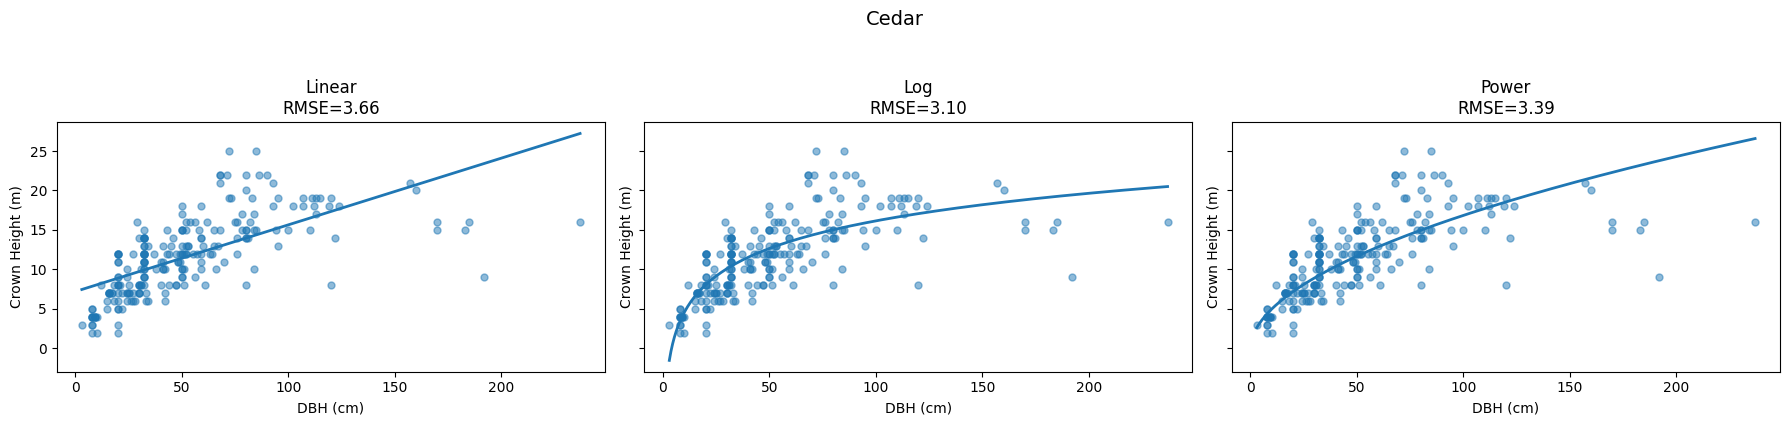

Species: Cedar
Linear: RMSE = 3.66
Log:    RMSE = 3.10
Power:  RMSE = 3.39
------------------------------------------------------------


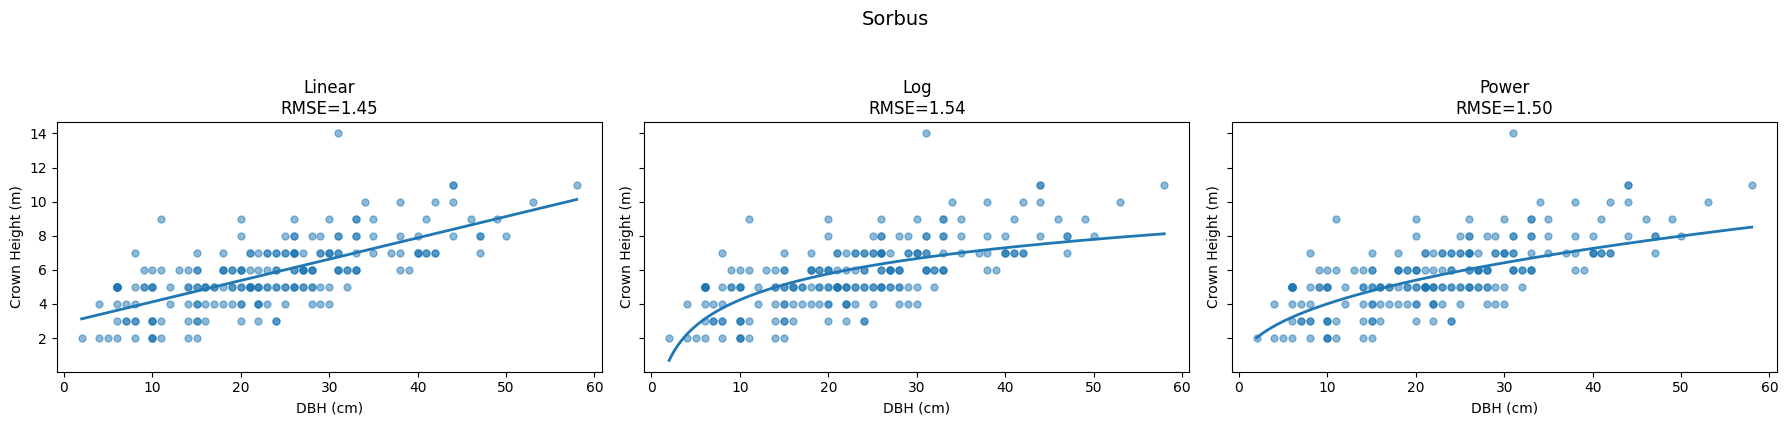

Species: Sorbus
Linear: RMSE = 1.45
Log:    RMSE = 1.54
Power:  RMSE = 1.50
------------------------------------------------------------


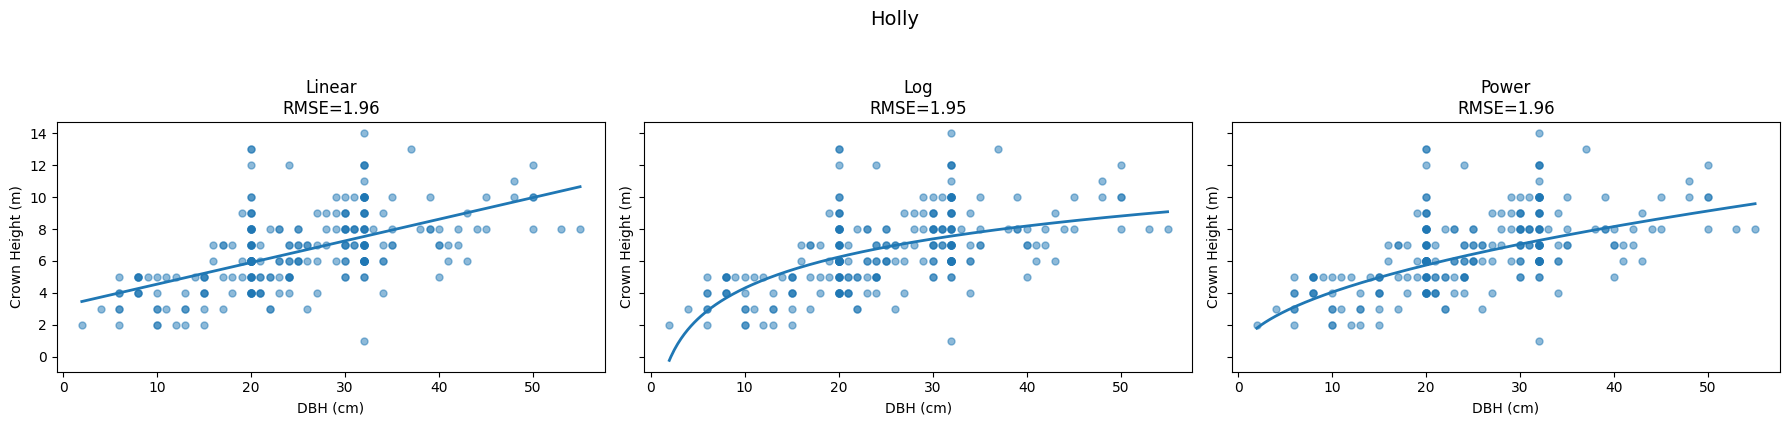

Species: Holly
Linear: RMSE = 1.96
Log:    RMSE = 1.95
Power:  RMSE = 1.96
------------------------------------------------------------


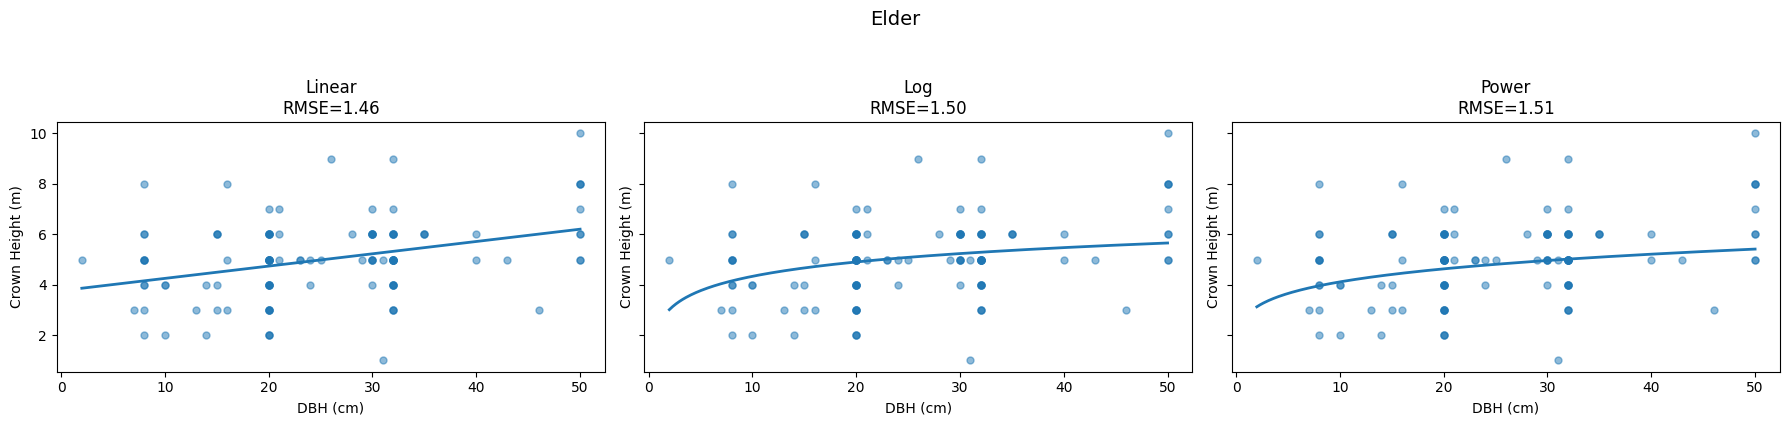

Species: Elder
Linear: RMSE = 1.46
Log:    RMSE = 1.50
Power:  RMSE = 1.51
------------------------------------------------------------


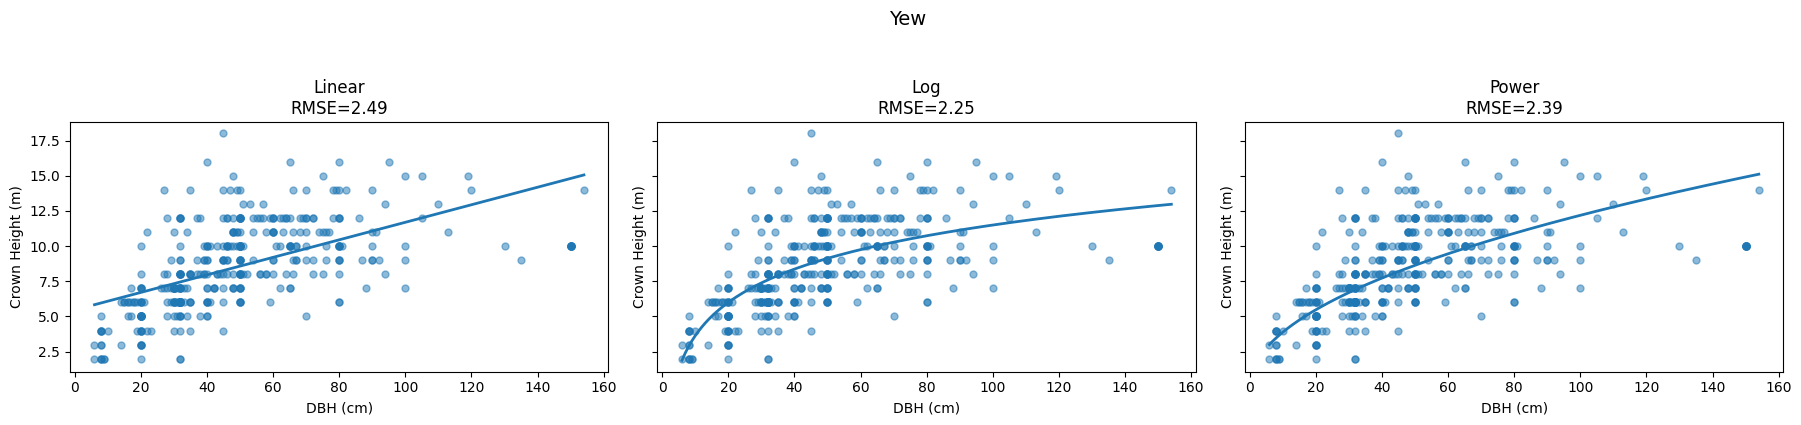

Species: Yew
Linear: RMSE = 2.49
Log:    RMSE = 2.25
Power:  RMSE = 2.39
------------------------------------------------------------


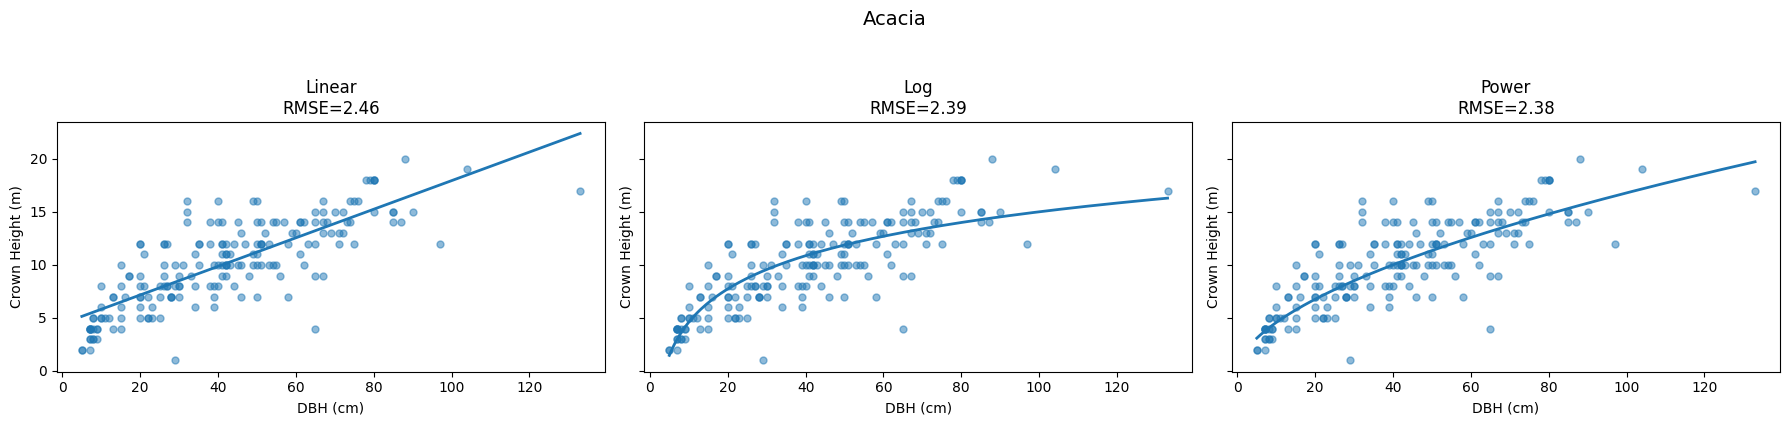

Species: Acacia
Linear: RMSE = 2.46
Log:    RMSE = 2.39
Power:  RMSE = 2.38
------------------------------------------------------------


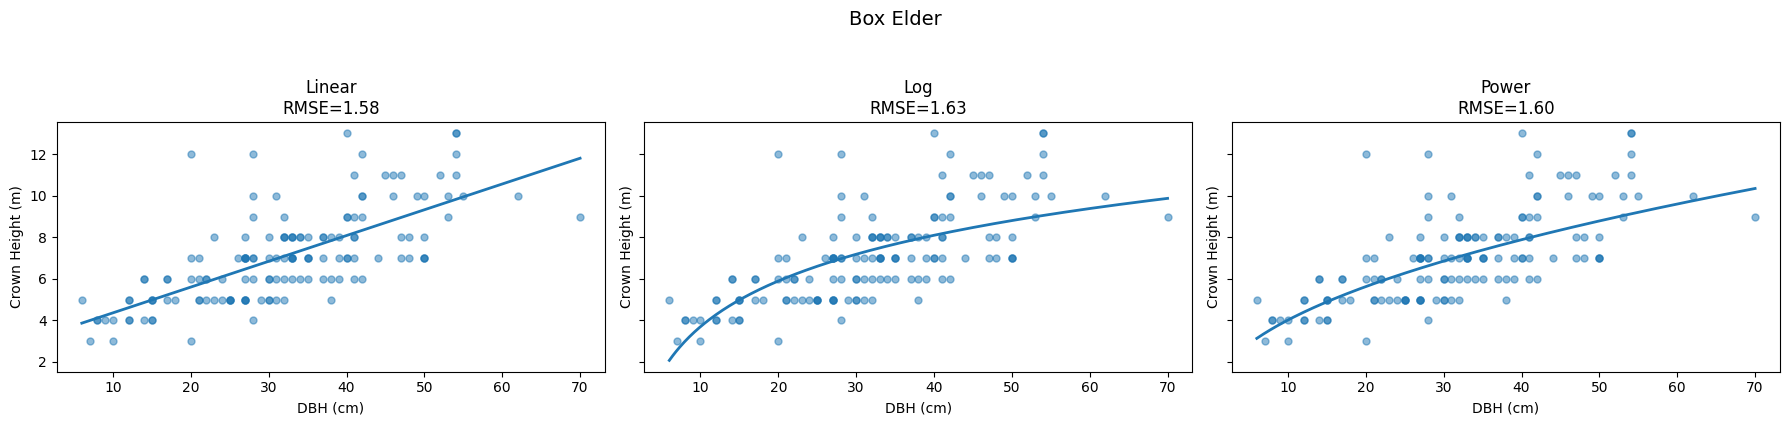

Species: Box Elder
Linear: RMSE = 1.58
Log:    RMSE = 1.63
Power:  RMSE = 1.60
------------------------------------------------------------


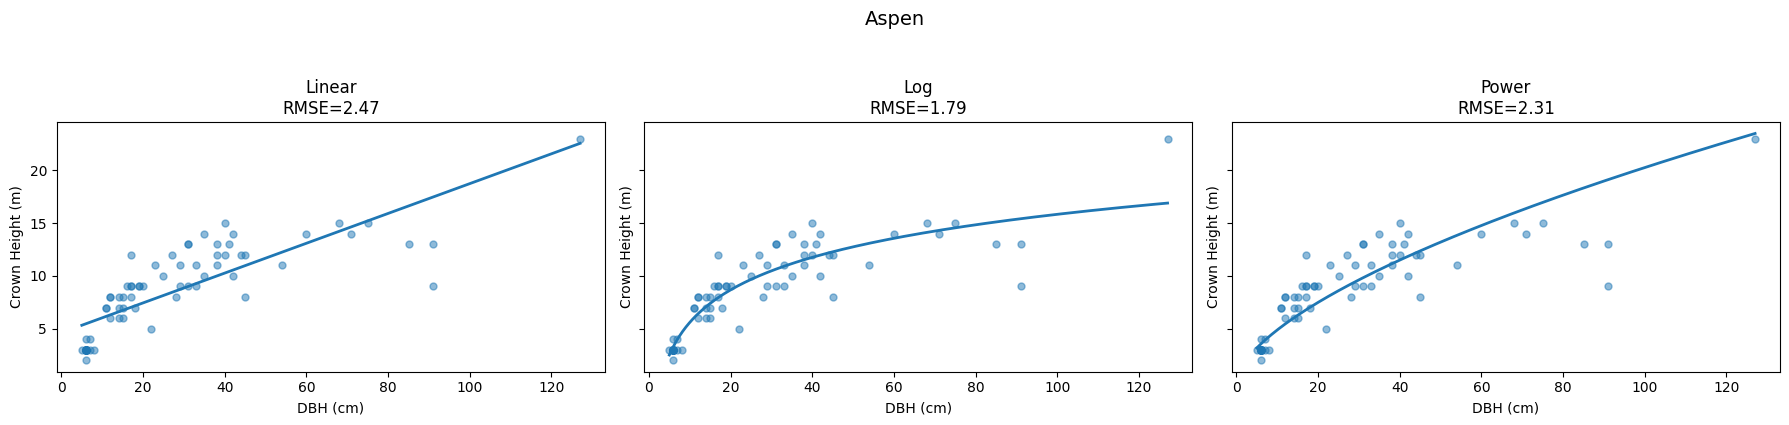

Species: Aspen
Linear: RMSE = 2.47
Log:    RMSE = 1.79
Power:  RMSE = 2.31
------------------------------------------------------------


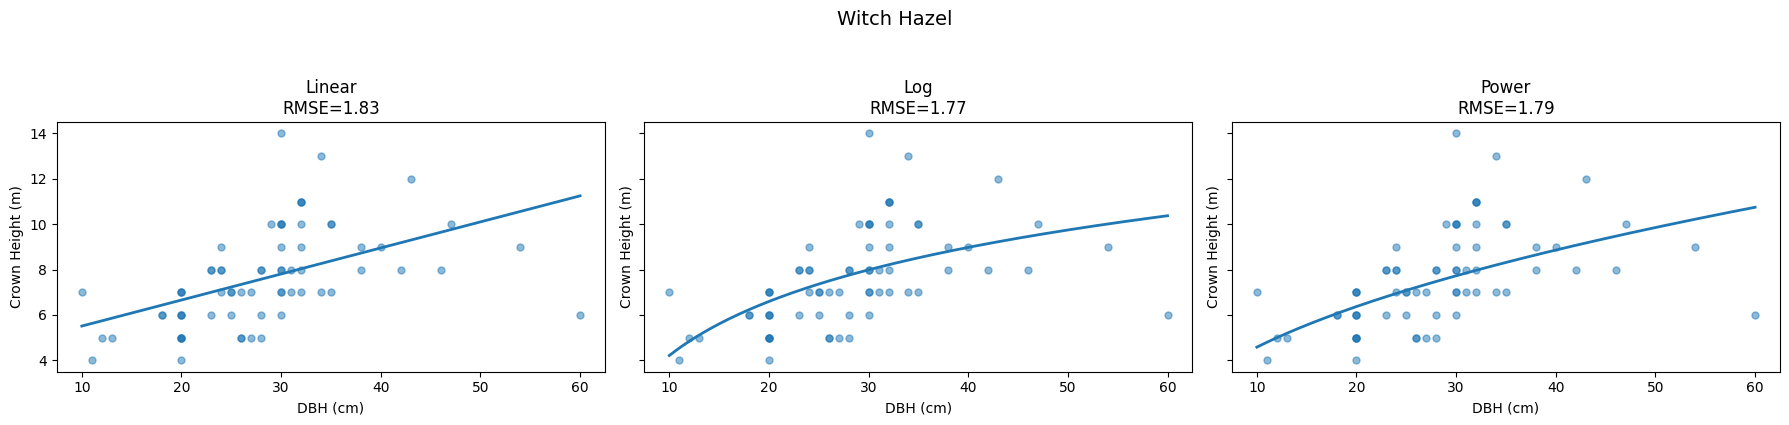

Species: Witch Hazel
Linear: RMSE = 1.83
Log:    RMSE = 1.77
Power:  RMSE = 1.79
------------------------------------------------------------


In [171]:
species_model_results = []
species_model_objects = {}

for species in eligible_species:
    species_df = df[df[species_col] == species].copy()

    # Keep only complete positive rows for fair comparison across all 3 models
    fit_df = species_df[[x_col, y_col]].dropna()
    fit_df = fit_df[(fit_df[x_col] > 0) & (fit_df[y_col] > 0)]

    # Skip if after filtering there are too few rows
    if len(fit_df) < min_threshold:
        continue

    x = fit_df[x_col].values
    y = fit_df[y_col].values

    model_dict = {}
    failure_flags = {"Linear": 0, "Log": 0, "Power": 0}

    # -------------------
    # Linear
    # -------------------
    try:
        predictor_lin, y_pred_lin, params_lin = fit_linear(x, y)
        rmse_lin = rmse(y, y_pred_lin)
        model_dict["Linear"] = {
            "predictor": predictor_lin,
            "rmse": rmse_lin,
            "params": params_lin
        }
    except Exception as e:
        failure_flags["Linear"] = 1
        model_dict["Linear"] = {
            "predictor": lambda z: np.full_like(np.asarray(z), np.nan, dtype=float),
            "rmse": np.nan,
            "params": None
        }

    # -------------------
    # Log
    # -------------------
    try:
        predictor_log, y_pred_log, params_log = fit_log(x, y)
        rmse_log = rmse(y, y_pred_log)
        model_dict["Log"] = {
            "predictor": predictor_log,
            "rmse": rmse_log,
            "params": params_log
        }
    except Exception as e:
        failure_flags["Log"] = 1
        model_dict["Log"] = {
            "predictor": lambda z: np.full_like(np.asarray(z), np.nan, dtype=float),
            "rmse": np.nan,
            "params": None
        }

    # -------------------
    # Power
    # -------------------
    try:
        predictor_power, y_pred_power, params_power = fit_power(x, y)
        rmse_power = rmse(y, y_pred_power)
        model_dict["Power"] = {
            "predictor": predictor_power,
            "rmse": rmse_power,
            "params": params_power
        }
    except Exception as e:
        failure_flags["Power"] = 1
        model_dict["Power"] = {
            "predictor": lambda z: np.full_like(np.asarray(z), np.nan, dtype=float),
            "rmse": np.nan,
            "params": None
        }

    # Store model objects for later reuse
    species_model_objects[species] = model_dict

    # Print the 3-panel plot to visually compare model fits for each species
    plot_species_fits(species, x, y, model_dict)

    # Print species-level RMSE summary underneath
    print(f"Species: {species}")
    print(f"Linear: RMSE = {model_dict['Linear']['rmse']:.2f}")
    print(f"Log:    RMSE = {model_dict['Log']['rmse']:.2f}")
    print(f"Power:  RMSE = {model_dict['Power']['rmse']:.2f}")
    print("-" * 60)

    # Store rows for summary dataframe
    for model_name in ["Linear", "Log", "Power"]:
        species_model_results.append({
            "species": species,
            "n_used": len(fit_df),
            "model_name": model_name,
            "rmse": model_dict[model_name]["rmse"],
            "failed": failure_flags[model_name]
        })

In [172]:
species_model_results_df = pd.DataFrame(species_model_results)

display(species_model_results_df.head(20))

,species,n_used,model_name,rmse,failed
0,Cherry,3850,Linear,1.843127,0
1,Cherry,3850,Log,1.745930,0
2,Cherry,3850,Power,1.756974,0
3,Oak,1735,Linear,3.045515,0
4,Oak,1735,Log,2.745405,0
5,Oak,1735,Power,2.818555,0
6,Lime,5957,Linear,3.092425,0
7,Lime,5957,Log,3.391286,0
8,Lime,5957,Power,3.140595,0
9,Silver Birch,1879,Linear,2.362261,0


In [173]:
#print a summary table of model performance across all species
print(f"--- Model Performance Across {len(species_model_results_df['species'].unique())} Species ---")
print(f"{'Model Name':<12} | {'Average RMSE':>12} | {'Median RMSE':>11} | {'Failure Rate':>12}")
print("-" * 60)

for _, row in model_performance_table.iterrows():
    print(
        f"{row['model_name']:<12} | "
        f"{row['average_rmse']:>12.2f} | "
        f"{row['median_rmse']:>11.2f} | "
        f"{row['failure_rate']:>11.1f}%"
    )

--- Model Performance Across 47 Species ---
Model Name   | Average RMSE | Median RMSE | Failure Rate
------------------------------------------------------------
Log          |         2.08 |        1.95 |         0.0%
Power        |         2.09 |        2.02 |         0.0%
Linear       |         2.15 |        2.05 |         0.0%


In [174]:
#inspect the best model for each species based on RMSE
best_model_per_species = (
    species_model_results_df
    .sort_values(["species", "rmse"])
    .groupby("species", as_index=False)
    .first()[["species", "model_name", "rmse", "n_used"]]
    .rename(columns={"model_name": "best_model", "rmse": "best_rmse"})
)

display(best_model_per_species)

,species,best_model,best_rmse,n_used
0,Acacia,Power,2.383184,188
1,Alder,Power,2.018258,909
2,Amelanchier,Log,0.783544,83
3,Apple,Log,1.429133,1282
4,Ash,Power,2.689263,2953
5,Aspen,Log,1.792178,73
6,Beech,Log,2.734706,643
7,Birch,Power,1.615892,500
8,Box Elder,Linear,1.580459,146
9,Cedar,Log,3.098112,227


In [175]:
# -----------------------------
# View all species and sample sizes
# -----------------------------
species_overview = (
    species_height_summary
    .reset_index()
    .rename(columns={species_col: "species"})
    .sort_values(["usable_pairs", "total_rows"], ascending=[False, False])
)

display(species_overview)

print(f"Total unique species: {species_overview['species'].nunique()}")

# -----------------------------
# Print all species names
# -----------------------------
all_species = sorted(df[species_col].dropna().unique().tolist())

for i, sp in enumerate(all_species, start=1):
    print(f"{i:>2}. {sp}")

,species,total_rows,missing_height,missing_dbh,usable_pairs
2,Lime,6566,339,371,5957
0,Cherry,4587,564,344,3850
11,Maple,3719,187,170,3415
15,Ash,3328,138,348,2953
24,Sycamore,3319,81,339,2940
...,...,...,...,...,...
65,Snowbell,10,10,0,0
70,Hickory,8,8,0,0
75,Yellowwood,6,6,3,0
93,Hackberry,1,1,1,0


Total unique species: 117
 1. Acacia
 2. Alder
 3. Almond
 4. Amelanchier
 5. Apple
 6. Armstrong Canadian Maple 
 7. Ash
 8. Aspen
 9. Bay
10. Beech
11. Birch
12. Blackthorn
13. Box
14. Box Elder
15. Bristol Whitebeam
16. Buckeye
17. Buddleia
18. Cabbage Palm
19. Catalpa
20. Cedar
21. Cherry
22. Chitalpa
23. Chusan Palm
24. Columella Elm
25. Conifer
26. Copper Beech
27. Cornel
28. Cotoneaster
29. Cypress
30. Dawn Redwood
31. Dawyck Beech
32. Dogwood
33. Douglas Fir
34. Downy Birch
35. Elder
36. Eleagnus
37. Elm
38. Eucalyptus
39. Feijoa
40. Field Maple
41. Fig
42. Filbert
43. Fir
44. Firethorn
45. Foxglove Tree
46. Gingko
47. Hackberry
48. Handkerchief Tree
49. Hawthorn
50. Hazel
51. Hemlock
52. Hiba
53. Hickory
54. Holly
55. Honey Locust
56. Hop Hornbeam
57. Hornbeam
58. Horse Chestnut
59. Ironwood
60. Judas Tree
61. Juniper
62. Katsura
63. Laburnum
64. Larch
65. Laurel
66. Lilac
67. Lime
68. Magnolia
69. Maple
70. Medlar
71. Monkey Puzzle
72. Mulberry
73. Nettle Tree
74. Oak
75. Pag

Okay so thought here was that now we have determined that log is the overall best (mean and median) for all the datasets with mising values, as the Judas tree is below the minimum usable pair threshold, create a deciduous tree set with all trees and see which model behaves the best. If log, then we can justify using log modelling globally across all species for interpolation.

In [176]:
#define evergreen set to match Emeka and Andreaa
evergreen_set = {
    "Bay", "Box", "Cabbage Palm", "Cedar", "Chusan Palm", "Conifer", "Cypress", "Douglas Fir", "Eleagnus",
    "Eucalyptus", "Feijoa", "Fir", "Firethorn", "Hiba", "Hemlock", "Holly", "Juniper", "Laurel", "Monkey Puzzle",
    "Pine", "Pittosporum", "Redwood", "Scots Pine", "Spruce", "Strawberry Tree", "Wedding Cake Tree", "Yew"
}

all_species = set(df["COMMON_NAME"].dropna().unique())

deciduous_set = all_species - evergreen_set

In [177]:
# -----------------------------
# Check deciduous set against species in data
# -----------------------------
species_in_data = set(df[species_col].dropna().unique())

matched_deciduous = sorted(species_in_data.intersection(deciduous_set))
missing_from_data = sorted(deciduous_set.difference(species_in_data))


In [178]:
# -----------------------------
# Deciduous-only subset (exclude Judas for fitting)
# -----------------------------
deciduous_df = df[df[species_col].isin(deciduous_set)].copy()

# Exclude Judas Tree from model fitting
deciduous_fit_df = deciduous_df[
    ~deciduous_df[species_col].str.contains("Judas", case=False, na=False)
].copy()

# Only complete and valid values
deciduous_fit_df = deciduous_fit_df[[x_col, y_col]].dropna()
deciduous_fit_df = deciduous_fit_df[
    (deciduous_fit_df[x_col] > 0) & (deciduous_fit_df[y_col] > 0)
]

print(f"Total deciduous rows (including Judas): {len(deciduous_df)}")
print(f"Rows used for fitting (excluding Judas): {len(deciduous_fit_df)}")

Total deciduous rows (including Judas): 48591
Rows used for fitting (excluding Judas): 40200


In [179]:
# -----------------------------
# Fit Linear / Log / Power on all deciduous trees
# -----------------------------
x_dec = deciduous_fit_df[x_col].values
y_dec = deciduous_fit_df[y_col].values

# Linear
predictor_dec_lin, y_pred_dec_lin, params_dec_lin = fit_linear(x_dec, y_dec)
rmse_dec_lin = rmse(y_dec, y_pred_dec_lin)

# Log
predictor_dec_log, y_pred_dec_log, params_dec_log = fit_log(x_dec, y_dec)
rmse_dec_log = rmse(y_dec, y_pred_dec_log)

# Power
predictor_dec_power, y_pred_dec_power, params_dec_power = fit_power(x_dec, y_dec)
rmse_dec_power = rmse(y_dec, y_pred_dec_power)

print("Deciduous group models fitted successfully.")
print(f"Number of observations used: {len(deciduous_fit_df)}")

Deciduous group models fitted successfully.
Number of observations used: 40200


In [180]:
# -----------------------------
# Deciduous group performance summary
# -----------------------------
deciduous_group_results = pd.DataFrame({
    "model_name": ["Linear", "Log", "Power"],
    "rmse": [rmse_dec_lin, rmse_dec_log, rmse_dec_power],
    "n_used": [len(deciduous_fit_df)] * 3,
    "params": [params_dec_lin, params_dec_log, params_dec_power]
}).sort_values("rmse").reset_index(drop=True)

display(deciduous_group_results)

print("--- Deciduous Group Model Performance ---")
print(f"{'Model Name':<12} | {'RMSE':>10} | {'N Used':>8}")
print("-" * 38)

for _, row in deciduous_group_results.iterrows():
    print(f"{row['model_name']:<12} | {row['rmse']:>10.3f} | {row['n_used']:>8}")

,model_name,rmse,n_used,params
0,Power,2.751841,40200,"{'a': 0.8843954890126272, 'b': 0.6482899860282..."
1,Linear,2.804262,40200,"{'intercept': 3.0584669695714624, 'slope': 0.1..."
2,Log,2.915650,40200,"{'intercept': -7.123856461069243, 'slope': 4.8..."


--- Deciduous Group Model Performance ---
Model Name   |       RMSE |   N Used
--------------------------------------
Power        |      2.752 |    40200
Linear       |      2.804 |    40200
Log          |      2.916 |    40200


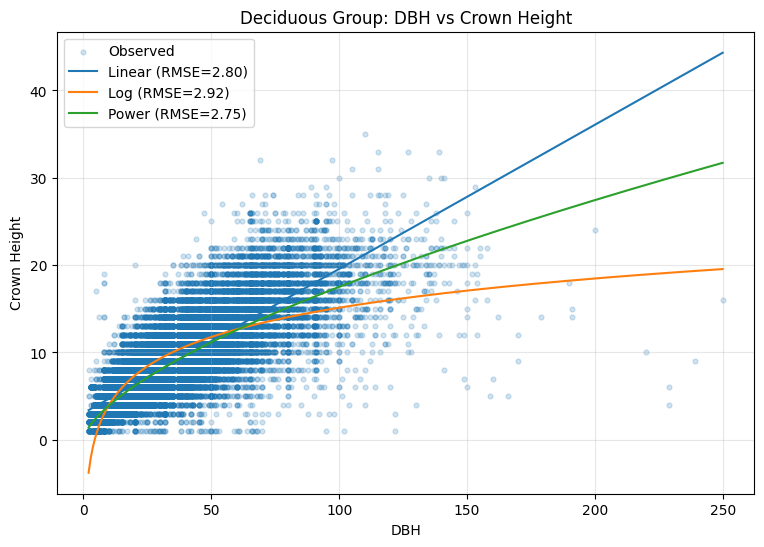

In [181]:
# -----------------------------
# Plot deciduous group fits
# -----------------------------
plt.figure(figsize=(9, 6))

plt.scatter(x_dec, y_dec, alpha=0.2, s=12, label="Observed")

x_range = np.linspace(x_dec.min(), x_dec.max(), 300)

plt.plot(
    x_range,
    predictor_dec_lin(x_range),
    label=f"Linear (RMSE={rmse_dec_lin:.2f})"
)

plt.plot(
    x_range,
    predictor_dec_log(x_range),
    label=f"Log (RMSE={rmse_dec_log:.2f})"
)

plt.plot(
    x_range,
    predictor_dec_power(x_range),
    label=f"Power (RMSE={rmse_dec_power:.2f})"
)

plt.xlabel("DBH")
plt.ylabel("Crown Height")
plt.title("Deciduous Group: DBH vs Crown Height")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Now we know that log actually performs the worst for deciduous trees, check the total evergreen set.

In [182]:
# -----------------------------
# Check evergreen set against species in data
# -----------------------------
species_in_data = set(df[species_col].dropna().unique())

matched_evergreen = sorted(species_in_data.intersection(evergreen_set))
missing_from_data = sorted(evergreen_set.difference(species_in_data))

print("Matched evergreen species in dataset:")
for sp in matched_evergreen:
    print(" -", sp)

print("\nEvergreen names not found in dataset:")
for sp in missing_from_data:
    print(" -", sp)

print(f"\nMatched evergreen species count: {len(matched_evergreen)}")

Matched evergreen species in dataset:
 - Bay
 - Box
 - Cabbage Palm
 - Cedar
 - Chusan Palm
 - Conifer
 - Cypress
 - Douglas Fir
 - Eleagnus
 - Eucalyptus
 - Feijoa
 - Fir
 - Firethorn
 - Hemlock
 - Hiba
 - Holly
 - Juniper
 - Laurel
 - Monkey Puzzle
 - Pine
 - Pittosporum
 - Redwood
 - Scots Pine
 - Spruce
 - Strawberry Tree
 - Wedding Cake Tree
 - Yew

Evergreen names not found in dataset:

Matched evergreen species count: 27


In [183]:
# -----------------------------
# Evergreen-only subset
# -----------------------------
evergreen_df = df[df[species_col].isin(evergreen_set)].copy()

# Only complete and valid values
evergreen_fit_df = evergreen_df[[x_col, y_col]].dropna()
evergreen_fit_df = evergreen_fit_df[
    (evergreen_fit_df[x_col] > 0) & (evergreen_fit_df[y_col] > 0)
]

print(f"Total evergreen rows: {len(evergreen_df)}")
print(f"Rows used for fitting: {len(evergreen_fit_df)}")

Total evergreen rows: 3508
Rows used for fitting: 2746


In [184]:
# -----------------------------
# Fit Linear / Log / Power on all evergreen trees
# -----------------------------
x_ever = evergreen_fit_df[x_col].values
y_ever = evergreen_fit_df[y_col].values

# Linear
predictor_ever_lin, y_pred_ever_lin, params_ever_lin = fit_linear(x_ever, y_ever)
rmse_ever_lin = rmse(y_ever, y_pred_ever_lin)

# Log
predictor_ever_log, y_pred_ever_log, params_ever_log = fit_log(x_ever, y_ever)
rmse_ever_log = rmse(y_ever, y_pred_ever_log)

# Power
predictor_ever_power, y_pred_ever_power, params_ever_power = fit_power(x_ever, y_ever)
rmse_ever_power = rmse(y_ever, y_pred_ever_power)

print("Evergreen group models fitted successfully.")
print(f"Number of observations used: {len(evergreen_fit_df)}")

Evergreen group models fitted successfully.
Number of observations used: 2746


In [185]:
# -----------------------------
# Evergreen group performance summary
# -----------------------------
evergreen_group_results = pd.DataFrame({
    "model_name": ["Linear", "Log", "Power"],
    "rmse": [rmse_ever_lin, rmse_ever_log, rmse_ever_power],
    "n_used": [len(evergreen_fit_df)] * 3,
    "params": [params_ever_lin, params_ever_log, params_ever_power]
}).sort_values("rmse").reset_index(drop=True)

display(evergreen_group_results)

print("--- Evergreen Group Model Performance ---")
print(f"{'Model Name':<12} | {'RMSE':>10} | {'N Used':>8}")
print("-" * 38)

for _, row in evergreen_group_results.iterrows():
    print(f"{row['model_name']:<12} | {row['rmse']:>10.3f} | {row['n_used']:>8}")

,model_name,rmse,n_used,params
0,Log,2.957535,2746,"{'intercept': -6.390987765466152, 'slope': 4.5..."
1,Power,3.006598,2746,"{'a': 0.961437275399907, 'b': 0.6164196605090713}"
2,Linear,3.154099,2746,"{'intercept': 4.438168043153845, 'slope': 0.12..."


--- Evergreen Group Model Performance ---
Model Name   |       RMSE |   N Used
--------------------------------------
Log          |      2.958 |     2746
Power        |      3.007 |     2746
Linear       |      3.154 |     2746


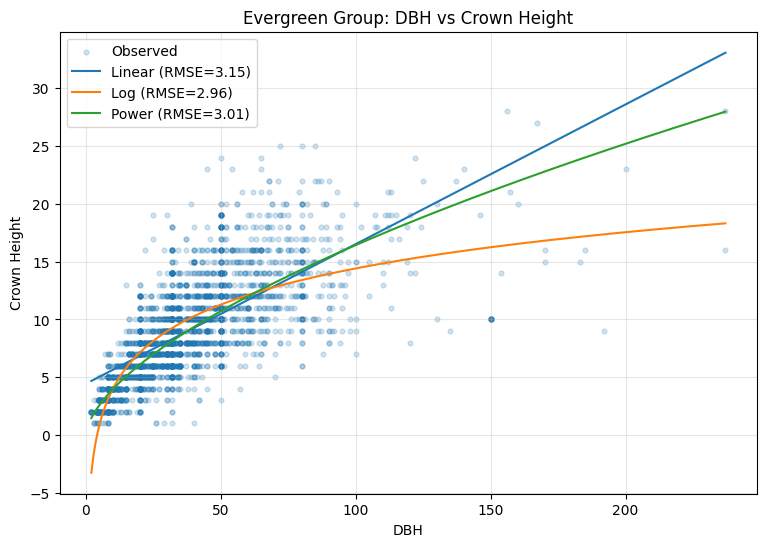

In [186]:
# -----------------------------
# Plot evergreen group fits
# -----------------------------
plt.figure(figsize=(9, 6))

plt.scatter(x_ever, y_ever, alpha=0.2, s=12, label="Observed")

x_range = np.linspace(x_ever.min(), x_ever.max(), 300)

plt.plot(
    x_range,
    predictor_ever_lin(x_range),
    label=f"Linear (RMSE={rmse_ever_lin:.2f})"
)

plt.plot(
    x_range,
    predictor_ever_log(x_range),
    label=f"Log (RMSE={rmse_ever_log:.2f})"
)

plt.plot(
    x_range,
    predictor_ever_power(x_range),
    label=f"Power (RMSE={rmse_ever_power:.2f})"
)

plt.xlabel("DBH")
plt.ylabel("Crown Height")
plt.title("Evergreen Group: DBH vs Crown Height")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Now we have confirmed that log is the best for evergreen. Go back to the species with missing values (with enough usable pairs) and confirm that this correlation is still present. 
Hypothesis:
Deciduous -> Power
Evergreen -> Log

In [187]:
# -----------------------------
# Classify each species into a tree group
# -----------------------------
def assign_tree_group(species):
    if pd.isna(species):
        return "unknown"
    if species in deciduous_set:
        return "deciduous"
    elif species in evergreen_set:
        return "evergreen"
    else:
        return "other"

df["tree_group"] = df[species_col].apply(assign_tree_group)

group_check = (
    df[[species_col, "tree_group"]]
    .drop_duplicates()
    .sort_values([ "tree_group", species_col ])
)

display(group_check.head(30))
print(df["tree_group"].value_counts(dropna=False))

,COMMON_NAME,tree_group
51,Acacia,deciduous
9,Alder,deciduous
5459,Almond,deciduous
28,Amelanchier,deciduous
10,Apple,deciduous
5175,Armstrong Canadian Maple,deciduous
0,Ash,deciduous
4524,Aspen,deciduous
1145,Beech,deciduous
11,Birch,deciduous


tree_group
deciduous    48591
unknown       3577
evergreen     3508
Name: count, dtype: int64


In [188]:
# -----------------------------
# Species needing interpolation and with enough usable pairs
# -----------------------------
species_interpolation_summary = (
    df.groupby(species_col)
    .agg(
        total_rows=(species_col, "size"),
        missing_height=(y_col, lambda x: x.isna().sum()),
        missing_dbh=(x_col, lambda x: x.isna().sum())
    )
)

usable_pairs = (
    df.dropna(subset=[species_col, x_col, y_col])
    .query(f"`{x_col}` > 0 and `{y_col}` > 0")
    .groupby(species_col)
    .size()
    .rename("usable_pairs")
)

species_interpolation_summary = species_interpolation_summary.join(usable_pairs, how="left")
species_interpolation_summary["usable_pairs"] = species_interpolation_summary["usable_pairs"].fillna(0).astype(int)

species_interpolation_summary["tree_group"] = [
    assign_tree_group(sp) for sp in species_interpolation_summary.index
]

# only species that:
# 1) have missing crown height values
# 2) have enough usable pairs to fit a species-level model
species_candidates = species_interpolation_summary[
    (species_interpolation_summary["missing_height"] > 0) &
    (species_interpolation_summary["usable_pairs"] >= min_threshold)
].copy()

species_candidates = species_candidates.sort_values(
    ["tree_group", "missing_height", "usable_pairs"],
    ascending=[True, False, False]
)

display(species_candidates)
print(f"Number of candidate species: {len(species_candidates)}")

,total_rows,missing_height,missing_dbh,usable_pairs,tree_group
COMMON_NAME,,,,,
Cherry,4587,564,344,3850,deciduous
Oak,2326,399,421,1735,deciduous
Lime,6566,339,371,5957,deciduous
Silver Birch,2183,238,118,1879,deciduous
Apple,1574,230,104,1282,deciduous
Hawthorn,1683,219,146,1368,deciduous
Rowan,967,215,109,709,deciduous
Birch,728,213,61,500,deciduous
Field Maple,1333,209,223,975,deciduous


Number of candidate species: 47


In [189]:
# -----------------------------
# Species-level model fitting for candidate species
# -----------------------------
candidate_species_model_results = []
candidate_species_model_objects = {}

for species in species_candidates.index:
    species_df = df[df[species_col] == species].copy()

    fit_df = species_df[[x_col, y_col]].dropna()
    fit_df = fit_df[(fit_df[x_col] > 0) & (fit_df[y_col] > 0)]

    x = fit_df[x_col].values
    y = fit_df[y_col].values

    model_dict = {}

    # Linear
    try:
        predictor_lin, y_pred_lin, params_lin = fit_linear(x, y)
        rmse_lin = rmse(y, y_pred_lin)
        model_dict["Linear"] = {
            "predictor": predictor_lin,
            "rmse": rmse_lin,
            "params": params_lin
        }
        candidate_species_model_results.append({
            "species": species,
            "tree_group": assign_tree_group(species),
            "model_name": "Linear",
            "rmse": rmse_lin,
            "n_used": len(fit_df),
            "missing_height": species_candidates.loc[species, "missing_height"]
        })
    except Exception:
        model_dict["Linear"] = {"predictor": None, "rmse": np.nan, "params": None}

    # Log
    try:
        predictor_log, y_pred_log, params_log = fit_log(x, y)
        rmse_log = rmse(y, y_pred_log)
        model_dict["Log"] = {
            "predictor": predictor_log,
            "rmse": rmse_log,
            "params": params_log
        }
        candidate_species_model_results.append({
            "species": species,
            "tree_group": assign_tree_group(species),
            "model_name": "Log",
            "rmse": rmse_log,
            "n_used": len(fit_df),
            "missing_height": species_candidates.loc[species, "missing_height"]
        })
    except Exception:
        model_dict["Log"] = {"predictor": None, "rmse": np.nan, "params": None}

    # Power
    try:
        predictor_power, y_pred_power, params_power = fit_power(x, y)
        rmse_power = rmse(y, y_pred_power)
        model_dict["Power"] = {
            "predictor": predictor_power,
            "rmse": rmse_power,
            "params": params_power
        }
        candidate_species_model_results.append({
            "species": species,
            "tree_group": assign_tree_group(species),
            "model_name": "Power",
            "rmse": rmse_power,
            "n_used": len(fit_df),
            "missing_height": species_candidates.loc[species, "missing_height"]
        })
    except Exception:
        model_dict["Power"] = {"predictor": None, "rmse": np.nan, "params": None}

    candidate_species_model_objects[species] = model_dict

candidate_species_model_results_df = pd.DataFrame(candidate_species_model_results)
display(candidate_species_model_results_df.head(20))

,species,tree_group,model_name,rmse,n_used,missing_height
0,Cherry,deciduous,Linear,1.843127,3850,564
1,Cherry,deciduous,Log,1.745930,3850,564
2,Cherry,deciduous,Power,1.756974,3850,564
3,Oak,deciduous,Linear,3.045515,1735,399
4,Oak,deciduous,Log,2.745405,1735,399
5,Oak,deciduous,Power,2.818555,1735,399
6,Lime,deciduous,Linear,3.092425,5957,339
7,Lime,deciduous,Log,3.391286,5957,339
8,Lime,deciduous,Power,3.140595,5957,339
9,Silver Birch,deciduous,Linear,2.362261,1879,238


In [190]:
# -----------------------------
# Best model per candidate species
# -----------------------------
best_model_candidate_species = (
    candidate_species_model_results_df
    .sort_values(["species", "rmse"])
    .groupby("species", as_index=False)
    .first()[["species", "tree_group", "model_name", "rmse", "n_used", "missing_height"]]
    .rename(columns={
        "model_name": "best_model",
        "rmse": "best_rmse"
    })
)

best_model_candidate_species = best_model_candidate_species.sort_values(
    ["tree_group", "best_model", "missing_height"],
    ascending=[True, True, False]
)

display(best_model_candidate_species)

,species,tree_group,best_model,best_rmse,n_used,missing_height
24,Lime,deciduous,Linear,3.092425,5957,339
11,Copper Beech,deciduous,Linear,2.707399,116,24
37,Sorbus,deciduous,Linear,1.448007,215,15
14,Elder,deciduous,Linear,1.461079,122,13
8,Box Elder,deciduous,Linear,1.580459,146,7
10,Cherry,deciduous,Log,1.745930,3850,564
27,Oak,deciduous,Log,2.745405,1735,399
36,Silver Birch,deciduous,Log,2.134775,1879,238
3,Apple,deciduous,Log,1.429133,1282,230
18,Hawthorn,deciduous,Log,1.294932,1368,219


In [191]:
# -----------------------------
# Counts and percentages of best model by tree group
# -----------------------------
model_group_counts = pd.crosstab(
    best_model_candidate_species["tree_group"],
    best_model_candidate_species["best_model"]
)

model_group_percent = pd.crosstab(
    best_model_candidate_species["tree_group"],
    best_model_candidate_species["best_model"],
    normalize="index"
) * 100

print("Counts:")
display(model_group_counts)

print("Percent within each tree group:")
display(model_group_percent.round(1))

Counts:


best_model,Linear,Log,Power
tree_group,,,
deciduous,5,20,16
evergreen,1,4,1


Percent within each tree group:


best_model,Linear,Log,Power
tree_group,,,
deciduous,12.2,48.8,39.0
evergreen,16.7,66.7,16.7


In [192]:
# -----------------------------
# Weighted summary by number of missing crown heights
# -----------------------------
weighted_model_summary = (
    best_model_candidate_species
    .groupby(["tree_group", "best_model"])["missing_height"]
    .sum()
    .reset_index()
    .rename(columns={"missing_height": "total_missing_to_fill"})
)

weighted_pivot = weighted_model_summary.pivot(
    index="tree_group",
    columns="best_model",
    values="total_missing_to_fill"
).fillna(0)

weighted_percent = weighted_pivot.div(weighted_pivot.sum(axis=1), axis=0) * 100

print("Weighted by number of missing values to be interpolated:")
display(weighted_pivot.astype(int))

print("Weighted percentages by missing values:")
display(weighted_percent.round(1))

Weighted by number of missing values to be interpolated:


best_model,Linear,Log,Power
tree_group,,,
deciduous,398,2876,1786
evergreen,187,75,61


Weighted percentages by missing values:


best_model,Linear,Log,Power
tree_group,,,
deciduous,7.9,56.8,35.3
evergreen,57.9,23.2,18.9


In [193]:
# -----------------------------
# Fit species-specific logarithmic models
# -----------------------------
species_log_models = {}
species_log_summary = []

for species in species_height_summary.index:
    species_df = df[df[species_col] == species].copy()

    fit_df = species_df[[x_col, y_col]].dropna()
    fit_df = fit_df[(fit_df[x_col] > 0) & (fit_df[y_col] > 0)]

    n_used = len(fit_df)

    if n_used >= min_threshold:
        x = fit_df[x_col].values
        y = fit_df[y_col].values

        try:
            predictor_log, y_pred_log, params_log = fit_log(x, y)
            rmse_log = rmse(y, y_pred_log)

            species_log_models[species] = {
                "predictor": predictor_log,
                "params": params_log,
                "rmse": rmse_log,
                "n_used": n_used
            }

            species_log_summary.append({
                "species": species,
                "n_used": n_used,
                "rmse_log": rmse_log
            })

        except Exception as e:
            print(f"Log fit failed for {species}: {e}")

species_log_summary_df = pd.DataFrame(species_log_summary).sort_values("rmse_log")
display(species_log_summary_df)

print(f"Number of species with species-specific log models: {len(species_log_models)}")

,species,n_used,rmse_log
17,Amelanchier,83,0.783544
18,Magnolia,101,0.911014
16,Sweetgum,134,1.185525
5,Hawthorn,1368,1.294932
32,Plum,627,1.296058
6,Rowan,709,1.372455
12,Pear,421,1.396949
30,Service Tree,97,1.422126
4,Apple,1282,1.429133
13,Gingko,188,1.488945


Number of species with species-specific log models: 47


In [194]:
# -----------------------------
# Fit logarithmic fallback models
# -----------------------------

# Deciduous fallback
deciduous_log_fit_df = df[
    (df[species_col].isin(deciduous_set)) &
    (~df[species_col].str.contains("Judas", case=False, na=False))
][[x_col, y_col]].dropna()

deciduous_log_fit_df = deciduous_log_fit_df[
    (deciduous_log_fit_df[x_col] > 0) & (deciduous_log_fit_df[y_col] > 0)
]

x_dec_log = deciduous_log_fit_df[x_col].values
y_dec_log = deciduous_log_fit_df[y_col].values

predictor_dec_log, y_pred_dec_log, params_dec_log = fit_log(x_dec_log, y_dec_log)
rmse_dec_log = rmse(y_dec_log, y_pred_dec_log)


# Evergreen fallback
evergreen_log_fit_df = df[
    df[species_col].isin(evergreen_set)
][[x_col, y_col]].dropna()

evergreen_log_fit_df = evergreen_log_fit_df[
    (evergreen_log_fit_df[x_col] > 0) & (evergreen_log_fit_df[y_col] > 0)
]

x_ever_log = evergreen_log_fit_df[x_col].values
y_ever_log = evergreen_log_fit_df[y_col].values

predictor_ever_log, y_pred_ever_log, params_ever_log = fit_log(x_ever_log, y_ever_log)
rmse_ever_log = rmse(y_ever_log, y_pred_ever_log)


# Global fallback
global_log_fit_df = df[[x_col, y_col]].dropna()
global_log_fit_df = global_log_fit_df[
    (global_log_fit_df[x_col] > 0) & (global_log_fit_df[y_col] > 0)
]

x_global_log = global_log_fit_df[x_col].values
y_global_log = global_log_fit_df[y_col].values

predictor_global_log, y_pred_global_log, params_global_log = fit_log(x_global_log, y_global_log)
rmse_global_log = rmse(y_global_log, y_pred_global_log)


fallback_summary = pd.DataFrame({
    "model_scope": ["deciduous_log", "evergreen_log", "global_log"],
    "n_used": [len(deciduous_log_fit_df), len(evergreen_log_fit_df), len(global_log_fit_df)],
    "rmse": [rmse_dec_log, rmse_ever_log, rmse_global_log],
    "params": [params_dec_log, params_ever_log, params_global_log]
})

display(fallback_summary)

,model_scope,n_used,rmse,params
0,deciduous_log,40200,2.915650,"{'intercept': -7.123856461069243, 'slope': 4.8..."
1,evergreen_log,2746,2.957535,"{'intercept': -6.390987765466152, 'slope': 4.5..."
2,global_log,43920,2.967566,"{'intercept': -7.030664405221216, 'slope': 4.7..."


In [195]:
# -----------------------------
# Assign tree group
# -----------------------------
def assign_tree_group(species):
    if pd.isna(species):
        return "other"
    elif species in deciduous_set:
        return "deciduous"
    elif species in evergreen_set:
        return "evergreen"
    else:
        return "other"

df["tree_group"] = df[species_col].apply(assign_tree_group)

In [196]:
# -----------------------------
# Interpolate missing crown height using logarithmic models
# -----------------------------
def interpolate_crown_height_log(row):
    observed_height = row[y_col]
    dbh = row[x_col]
    species = row[species_col]
    tree_group = row["tree_group"]

    # Keep observed values
    if pd.notna(observed_height):
        return pd.Series([observed_height, 0, "observed", "observed"])

    # Cannot interpolate without usable DBH
    if pd.isna(dbh) or dbh <= 0:
        return pd.Series([np.nan, 0, "missing_no_dbh", "none"])

    # 1. Species-specific logarithmic model
    if species in species_log_models:
        pred = species_log_models[species]["predictor"](np.array([dbh]))[0]
        return pd.Series([pred, 1, "species_log", species])

    # 2. Deciduous fallback (includes Judas)
    if tree_group == "deciduous":
        pred = predictor_dec_log(np.array([dbh]))[0]
        return pd.Series([pred, 1, "deciduous_log_fallback", "deciduous_group"])

    # 3. Evergreen fallback
    if tree_group == "evergreen":
        pred = predictor_ever_log(np.array([dbh]))[0]
        return pd.Series([pred, 1, "evergreen_log_fallback", "evergreen_group"])

    # 4. Global fallback
    pred = predictor_global_log(np.array([dbh]))[0]
    return pd.Series([pred, 1, "global_log_fallback", "global_group"])


df[[
    "CROWN_HEIGHT_interpolated",
    "height_imputed_flag",
    "height_model_source",
    "height_model_group"
]] = df.apply(interpolate_crown_height_log, axis=1)

In [197]:
# -----------------------------
# Clip impossible negative crown heights
# -----------------------------
df["CROWN_HEIGHT_interpolated"] = df["CROWN_HEIGHT_interpolated"].clip(lower=0)

In [198]:
# -----------------------------
# Interpolation summary
# -----------------------------
print("Original missing crown height values:", df[y_col].isna().sum())
print("Remaining missing after interpolation:", df["CROWN_HEIGHT_interpolated"].isna().sum())
print("Number of imputed values:", int(df["height_imputed_flag"].sum()))

print("\nModel source counts:")
display(df["height_model_source"].value_counts(dropna=False).rename_axis("source").reset_index(name="count"))

Original missing crown height values: 8612
Remaining missing after interpolation: 2565
Number of imputed values: 6047

Model source counts:


,source,count
0,observed,47064
1,species_log,3561
2,missing_no_dbh,2565
3,global_log_fallback,1862
4,deciduous_log_fallback,579
5,evergreen_log_fallback,45


In [199]:
# -----------------------------
# Check Judas Tree rows
# -----------------------------
judas_rows = df[df[species_col].str.contains("Judas", case=False, na=False)].copy()

display(
    judas_rows[
        [species_col, x_col, y_col,
         "CROWN_HEIGHT_interpolated",
         "height_imputed_flag",
         "height_model_source",
         "height_model_group"]
    ]
)

,COMMON_NAME,DBH_clean,CROWN_HEIGHT_clean,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source,height_model_group
986,Judas Tree,NaN,NaN,NaN,0,missing_no_dbh,none
991,Judas Tree,NaN,NaN,NaN,0,missing_no_dbh,none
992,Judas Tree,NaN,NaN,NaN,0,missing_no_dbh,none
1205,Judas Tree,6.0,NaN,1.530435,1,deciduous_log_fallback,deciduous_group
1213,Judas Tree,6.0,NaN,1.530435,1,deciduous_log_fallback,deciduous_group
...,...,...,...,...,...,...,...
55168,Judas Tree,6.0,NaN,1.530435,1,deciduous_log_fallback,deciduous_group
55169,Judas Tree,6.0,NaN,1.530435,1,deciduous_log_fallback,deciduous_group
55170,Judas Tree,6.0,NaN,1.530435,1,deciduous_log_fallback,deciduous_group
55171,Judas Tree,6.0,NaN,1.530435,1,deciduous_log_fallback,deciduous_group


In [200]:
clipped_rows = df[df["CROWN_HEIGHT_interpolated"] == 0]
print("Number of clipped values:", len(clipped_rows))
display(clipped_rows.head())

Number of clipped values: 234


,OBJECTID,ASSET_ID,SITE_NAME,PLOT_NO,FEATURE_ID,LOCATION,TYPE,PRIM_MEAS,UNIT,SITE_CODE,...,created_date,last_edited_user,last_edited_date,DBH_clean,CROWN_HEIGHT_clean,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source,height_model_group
267,26609618,PK00293136,Air Balloon Road,200002.5,NaN,NaN,PK: Tree - Highways Adopted,1,Number,4525213,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,6.0,NaN,deciduous,0.0,1,species_log,Lime
402,26609753,00824454,Sturminster Close,200021.0,NaN,NaN,PK: Tree - Highways Adopted,1,Number,4527381,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,6.0,NaN,deciduous,0.0,1,species_log,Lime
406,26609757,00824455,Sturminster Close,200022.0,NaN,NaN,PK: Tree - Highways Adopted,1,Number,4527381,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,6.0,NaN,deciduous,0.0,1,species_log,Lime
571,26609922,PK00302475,Summerhill Road,200007.5,NaN,NaN,PK: Tree - Highways Adopted,1,Number,4532165,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,6.0,NaN,deciduous,0.0,1,species_log,Lime
654,26610005,00820915,Gloucester Road,200001.2,SORAUCAS,NaN,PK: Tree - Highways Adopted,1,Number,4523622,...,2026/03/10 05:14:23+00,PARKS_EDIT,2026/03/10 05:14:23+00,6.0,NaN,deciduous,0.0,1,species_log,Lime
